In [38]:
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple, Dict, Any
import colorsys, itertools, math, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex
from matplotlib.patches import Patch, Rectangle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import re # For parsing the list of tuples from CSV
import sys # For debug printing to stderr

In [39]:
# ---------------------------------------------------------------------
# 0. palette helpers
# ---------------------------------------------------------------------
BASE_COLOURS = {
    "NewMC":              "#ffcc99",  # Light orange
    "DR":                 "#ffcccc",  # Light red
    "NewMC_Expand":       "#ccffcc",  # Light green
    "NewMC_Restricted":   "#ccccff",  # Light blue
    "NewMC_Biased":       "#ffffcc",  # Light yellow
    "NewMC_Restricted_Expand": "#ffccff", # Light magenta
    "NewMC_Biased_Expand":    "#ccffff", # Light cyan
    "Kawasaki":           "#ffcccc",  # Light red
    "Kawasaki_Black":     "#000000",  # Dark black
}

def _anchor_colour(stem:str)->str:
    for k in sorted(BASE_COLOURS,key=len,reverse=True):
        if stem.startswith(k): return BASE_COLOURS[k]
    return "#808080"

def _tint_red(hex_colour:str,factor:float)->str:
    r,g,b=to_rgb(hex_colour)
    r=min(1.0, r*factor)
    return to_hex((r,g,b))

def _tint_green(hex_colour:str,factor:float)->str:
    r,g,b=to_rgb(hex_colour)
    g=min(1.0, g*factor)
    return to_hex((r,g,b))

def _tint_blue(hex_colour:str,factor:float)->str:
    r,g,b=to_rgb(hex_colour)
    b=min(1.0, b*factor)
    return to_hex((r,g,b))

def get_distinct_colors(n):
    """
    Generates n distinct colors. First color is black.
    """
    colors = ["#000000"]  # Black for the first color
    if n > 1:
        # Use HSV to get perceptually distinct colors
        # Start hue from a non-zero value to avoid very dark colors close to black
        for i in range(n - 1):
            hue = (i / (n - 1)) * 0.8 + 0.1 # Spread hues between 0.1 and 0.9
            # Ensure good saturation and value for visibility
            saturation = 0.8 # Fixed saturation
            value = 0.75 # Fixed value
            rgb = colorsys.hsv_to_rgb(hue, saturation, value)
            colors.append(to_hex(rgb))
    return colors

In [40]:
# ---------------------------------------------------------------------
# 1. filename / colour / label factory
# ---------------------------------------------------------------------
def build_filenames(*, BJ:str, include_kawasaki:bool,
                      base_variants:List[str], signifiers:List[List[str]], cluster_types:List[str]
                    )->Tuple[List[str],List[str],List[str],List[str],List[str],List[str]]:
    csv,tbl,col,leg,leg_col,expand=[],[],[],[],[],[]

    if include_kawasaki:
        # Kawasaki specific filename format
        fn=f"BJ={BJ}_Kawasaki_0_tol0.00_scp0.00.csv"
        print(f"Trying file: {fn}", file=sys.stderr)
        csv.append(fn)
        tbl.append("Kawasaki")
        col.append(BASE_COLOURS["Kawasaki_Black"])
        leg.append("Kawasaki")
        leg_col.append(BASE_COLOURS["Kawasaki_Black"])

    # Iterate through base variants, cluster types, and signifier combinations
    for stem in base_variants:
        for ct in cluster_types:
            anchor = _anchor_colour(stem)
            name = f"{stem}_{ct}"
            # Assuming signifiers[0] is for 'tol' and signifiers[1] is for 'scp'
            for j, signifier_1 in enumerate(signifiers[0]): # e.g., tol values
                for k, signifier_2 in enumerate(signifiers[1]): # e.g., scp values
                    fn_signifier = f"BJ={BJ}_{name}_{signifier_1}_{signifier_2}.csv"
                    csv.append(fn_signifier)
                    tbl.append(f"{name}_{signifier_1}_{signifier_2}")

                    # Calculate tint factors based on position in both loops
                    # Using much smaller tint ranges for subtler variation
                    tint1 = 0.8 + (0.4 * j/len(signifiers[0])) # First tint varies from 0.8 to 1.2
                    tint2 = 0.8 + (0.4 * k/len(signifiers[1])) # Second tint varies from 0.8 to 1.2
                    # Apply both tints sequentially
                    tinted_color = _tint_red(_tint_green(anchor, tint1), tint2)
                    col.append(tinted_color)

                    # Only add to legend for specific iterations (e.g., first and last of the inner loop)
                    # This helps prevent an overly cluttered legend
                    if k == 0 or k == len(signifiers[1])-1:
                        leg.append(f"{name}_{signifier_1}_{signifier_2}")
                        leg_col.append(tinted_color)
                    expand.append(fn_signifier)
    return csv,tbl,col,leg,leg_col,expand

In [41]:
# ---------------------------------------------------------------------
# 3. Cluster Analysis Module - Boundary and Interior Size Tracking
# ---------------------------------------------------------------------

def analyze_cluster_sizes(csv_files, *, table_labels, curve_colours, legend_labels=None, legend_colours=None):
    """
    Analyzes and plots cluster boundary and interior sizes as a function of iterations.
    Creates individual charts for each file with dynamic cluster detection.
    
    Parameters:
    - csv_files: List of CSV file paths
    - table_labels: Labels for each CSV file
    - curve_colours: Colors for each CSV file
    - legend_labels: Optional legend labels
    - legend_colours: Optional legend colors
    """
    
    print(f"\n--- Starting Cluster Size Analysis for {len(csv_files)} files ---", file=sys.stderr)
    
    plt.rcParams.update({'font.size': 10})
    
    # Process each file individually
    for csv_file, table_label, curve_color in zip(csv_files, table_labels, curve_colours):
        file_path = Path(csv_file)
        if not file_path.is_file():
            print(f"⚠️  Skipping {csv_file}: File not found", file=sys.stderr)
            continue
            
        try:
            # Read CSV and detect cluster columns
            df = pd.read_csv(file_path)
            
            # Find all cluster boundary and interior columns
            boundary_cols = [col for col in df.columns if col.startswith('BoundarySize_Cluster')]
            interior_cols = [col for col in df.columns if col.startswith('InteriorSize_Cluster')]
            
            # Extract cluster numbers and sort them
            cluster_numbers = []
            for col in boundary_cols:
                cluster_num = int(col.replace('BoundarySize_Cluster', ''))
                cluster_numbers.append(cluster_num)
            cluster_numbers = sorted(list(set(cluster_numbers)))
            
            num_clusters = len(cluster_numbers)
            if num_clusters == 0:
                print(f"⚠️  No cluster data found in {csv_file}", file=sys.stderr)
                continue
                
            print(f"📊 Processing {csv_file}: Found {num_clusters} clusters", file=sys.stderr)
            
            # Create figure for this file
            fig = plt.figure(figsize=(16, 10))
            fig.suptitle(f'Cluster Size Analysis: {table_label}', fontsize=16, fontweight='bold')
            
            # Calculate grid layout
            if num_clusters <= 2:
                rows, cols = 1, num_clusters
            elif num_clusters <= 4:
                rows, cols = 2, 2
            elif num_clusters <= 6:
                rows, cols = 2, 3
            elif num_clusters <= 9:
                rows, cols = 3, 3
            else:
                rows, cols = 4, int(np.ceil(num_clusters / 4))
            
            # Get iterations (x-axis)
            iterations = np.arange(len(df))
            
            # Generate distinct colors for clusters
            cluster_colors = get_distinct_colors(num_clusters)
            
            # Plot each cluster
            for i, cluster_num in enumerate(cluster_numbers):
                ax = fig.add_subplot(rows, cols, i + 1)
                
                boundary_col = f'BoundarySize_Cluster{cluster_num}'
                interior_col = f'InteriorSize_Cluster{cluster_num}'
                
                if boundary_col in df.columns and interior_col in df.columns:
                    # Get data, handling NaN values
                    boundary_data = df[boundary_col].fillna(0)
                    interior_data = df[interior_col].fillna(0)
                    
                    # Plot boundary and interior sizes
                    ax.plot(iterations, boundary_data, 
                           label='Boundary', 
                           color=cluster_colors[i], 
                           linewidth=2, 
                           alpha=0.8)
                    
                    ax.plot(iterations, interior_data, 
                           label='Interior', 
                           color=cluster_colors[i], 
                           linewidth=2, 
                           linestyle='--', 
                           alpha=0.8)
                    
                    # Calculate total cluster size
                    total_size = boundary_data + interior_data
                    ax.plot(iterations, total_size, 
                           label='Total', 
                           color='gray', 
                           linewidth=1, 
                           alpha=0.6)
                    
                    # Formatting
                    ax.set_title(f'Cluster {cluster_num}', fontweight='bold')
                    ax.set_xlabel('Iteration')
                    ax.set_ylabel('Number of Cells')
                    ax.grid(True, alpha=0.3)
                    ax.legend(fontsize=8)
                    
                    # Add statistics text
                    final_boundary = boundary_data.iloc[-1] if len(boundary_data) > 0 else 0
                    final_interior = interior_data.iloc[-1] if len(interior_data) > 0 else 0
                    final_total = final_boundary + final_interior
                    
                    stats_text = f'Final: B={int(final_boundary)}, I={int(final_interior)}, T={int(final_total)}'
                    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                           fontsize=8, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                else:
                    ax.text(0.5, 0.5, f'No data for\nCluster {cluster_num}', 
                           transform=ax.transAxes, ha='center', va='center')
                    ax.set_title(f'Cluster {cluster_num} (No Data)', fontweight='bold')
            
            # Remove empty subplots
            for i in range(len(cluster_numbers), rows * cols):
                fig.delaxes(fig.add_subplot(rows, cols, i + 1))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\n📈 Summary for {table_label}:")
            print(f"   Total clusters: {num_clusters}")
            for cluster_num in cluster_numbers:
                boundary_col = f'BoundarySize_Cluster{cluster_num}'
                interior_col = f'InteriorSize_Cluster{cluster_num}'
                
                if boundary_col in df.columns and interior_col in df.columns:
                    boundary_data = df[boundary_col].fillna(0)
                    interior_data = df[interior_col].fillna(0)
                    
                    final_boundary = boundary_data.iloc[-1] if len(boundary_data) > 0 else 0
                    final_interior = interior_data.iloc[-1] if len(interior_data) > 0 else 0
                    
                    avg_boundary = boundary_data.mean()
                    avg_interior = interior_data.mean()
                    
                    print(f"   Cluster {cluster_num}: Final B={int(final_boundary)}, I={int(final_interior)} | "
                          f"Avg B={avg_boundary:.1f}, I={avg_interior:.1f}")
            
        except Exception as e:
            print(f"❌ Error processing {csv_file}: {e}", file=sys.stderr)
            continue
    
    print(f"\n--- Cluster Size Analysis Complete ---", file=sys.stderr)


def batch_cluster_analysis(*base_filenames):
    """
    Convenience function to analyze cluster sizes for multiple files.
    
    Parameters:
    - base_filenames: Base names of CSV files (without .csv extension)
    """
    csv_files = [f"{base_name}.csv" for base_name in base_filenames]
    table_labels = list(base_filenames)
    
    # Generate colors for the files
    num_files = len(csv_files)
    curve_colours = get_distinct_colors(num_files)
    
    analyze_cluster_sizes(
        csv_files,
        table_labels=table_labels,
        curve_colours=curve_colours
    )


In [42]:
# ---------------------------------------------------------------------
# 4. Standalone Cluster Analysis Usage Examples
# ---------------------------------------------------------------------

print("=== Standalone Cluster Analysis Examples ===")
print("ℹ️  NOTE: Cluster analysis is now integrated into the main batch drivers!")
print("   - Use simple_batch(..., plot_clusters=True) for streamlined processing")
print("   - Use run_visualizations(..., plot_clusters=True) for complex workflows")
print("")
print("   For standalone cluster analysis, you can still use:")
print("   • batch_cluster_analysis('file1', 'file2', ...) - Simple multi-file analysis")
print("   • analyze_cluster_sizes(csv_files, table_labels, curve_colours) - Custom analysis")
print("")

# Example: Standalone cluster analysis (optional - use when batch drivers aren't suitable)
example_files = [
    "BJ=-0.44_Kawasaki_0_tol0.00_scp0.50",
    "BJ=-0.44_DR_1_tol0.50_scp0.50",
    "BJ=-0.44_DR_2_tol0.50_scp0.50"
]

existing_files = [f for f in example_files if Path(f"{f}.csv").is_file()]

if existing_files:
    print(f"📁 Available example files: {len(existing_files)}")
    for f in existing_files:
        print(f"   - {f}")
    
    print(f"\n🔧 To run standalone cluster analysis on these files:")
    print(f"   batch_cluster_analysis(*{existing_files})")
    print(f"\n💡 Or use the integrated batch driver (recommended):")
    print(f"   simple_batch(*{existing_files}, plot_clusters=True)")
else:
    print("📂 No example files found in current directory")
    csv_files = [f.name for f in Path(".").glob("*.csv")][:5]  # Show first 5
    if csv_files:
        print(f"   Available CSV files: {csv_files}")

print("\n" + "="*60)


=== Standalone Cluster Analysis Examples ===
ℹ️  NOTE: Cluster analysis is now integrated into the main batch drivers!
   - Use simple_batch(..., plot_clusters=True) for streamlined processing
   - Use run_visualizations(..., plot_clusters=True) for complex workflows

   For standalone cluster analysis, you can still use:
   • batch_cluster_analysis('file1', 'file2', ...) - Simple multi-file analysis
   • analyze_cluster_sizes(csv_files, table_labels, curve_colours) - Custom analysis

📁 Available example files: 3
   - BJ=-0.44_Kawasaki_0_tol0.00_scp0.50
   - BJ=-0.44_DR_1_tol0.50_scp0.50
   - BJ=-0.44_DR_2_tol0.50_scp0.50

🔧 To run standalone cluster analysis on these files:
   batch_cluster_analysis(*['BJ=-0.44_Kawasaki_0_tol0.00_scp0.50', 'BJ=-0.44_DR_1_tol0.50_scp0.50', 'BJ=-0.44_DR_2_tol0.50_scp0.50'])

💡 Or use the integrated batch driver (recommended):
   simple_batch(*['BJ=-0.44_Kawasaki_0_tol0.00_scp0.50', 'BJ=-0.44_DR_1_tol0.50_scp0.50', 'BJ=-0.44_DR_2_tol0.50_scp0.50'], plot_

=== Example 2: Advanced Cluster Analysis with Custom Colors ===

🔍 Kawasaki Method Comparison:
   Analyzing 2 files



--- Starting Cluster Size Analysis for 2 files ---
📊 Processing BJ=-0.44_Kawasaki_0_tol0.00_scp0.50.csv: Found 2 clusters


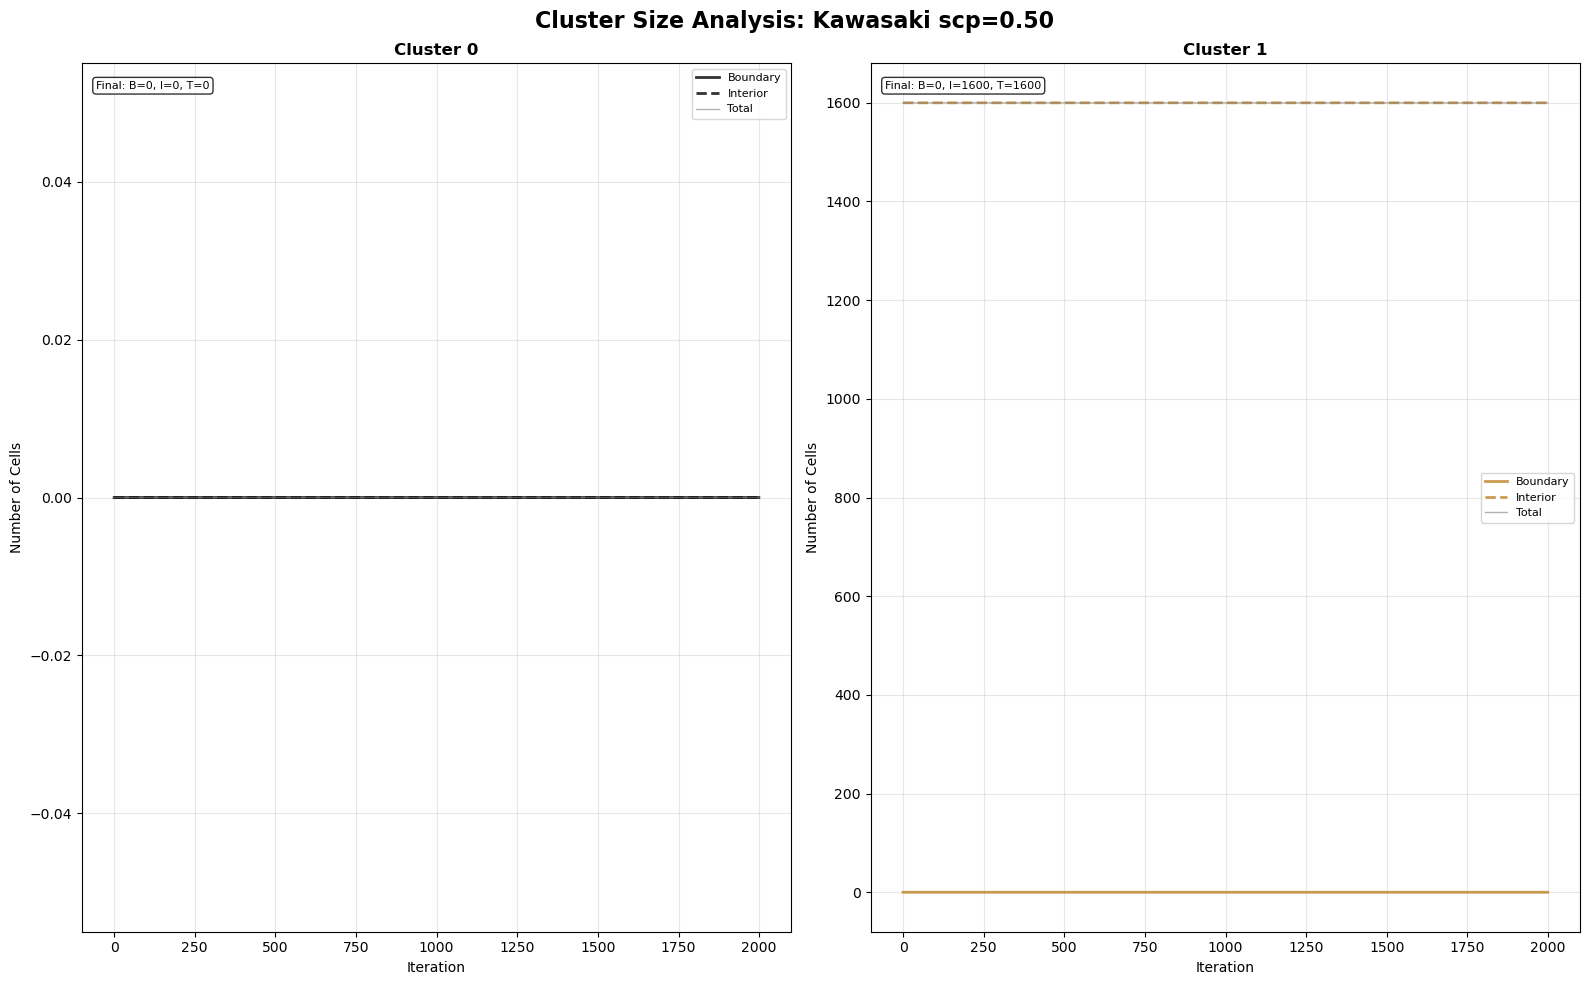


📈 Summary for Kawasaki scp=0.50:
   Total clusters: 2
   Cluster 0: Final B=0, I=0 | Avg B=0.0, I=0.0
   Cluster 1: Final B=0, I=1600 | Avg B=0.0, I=1600.0


📊 Processing BJ=-0.44_Kawasaki_0_tol0.00_scp0.00.csv: Found 2 clusters


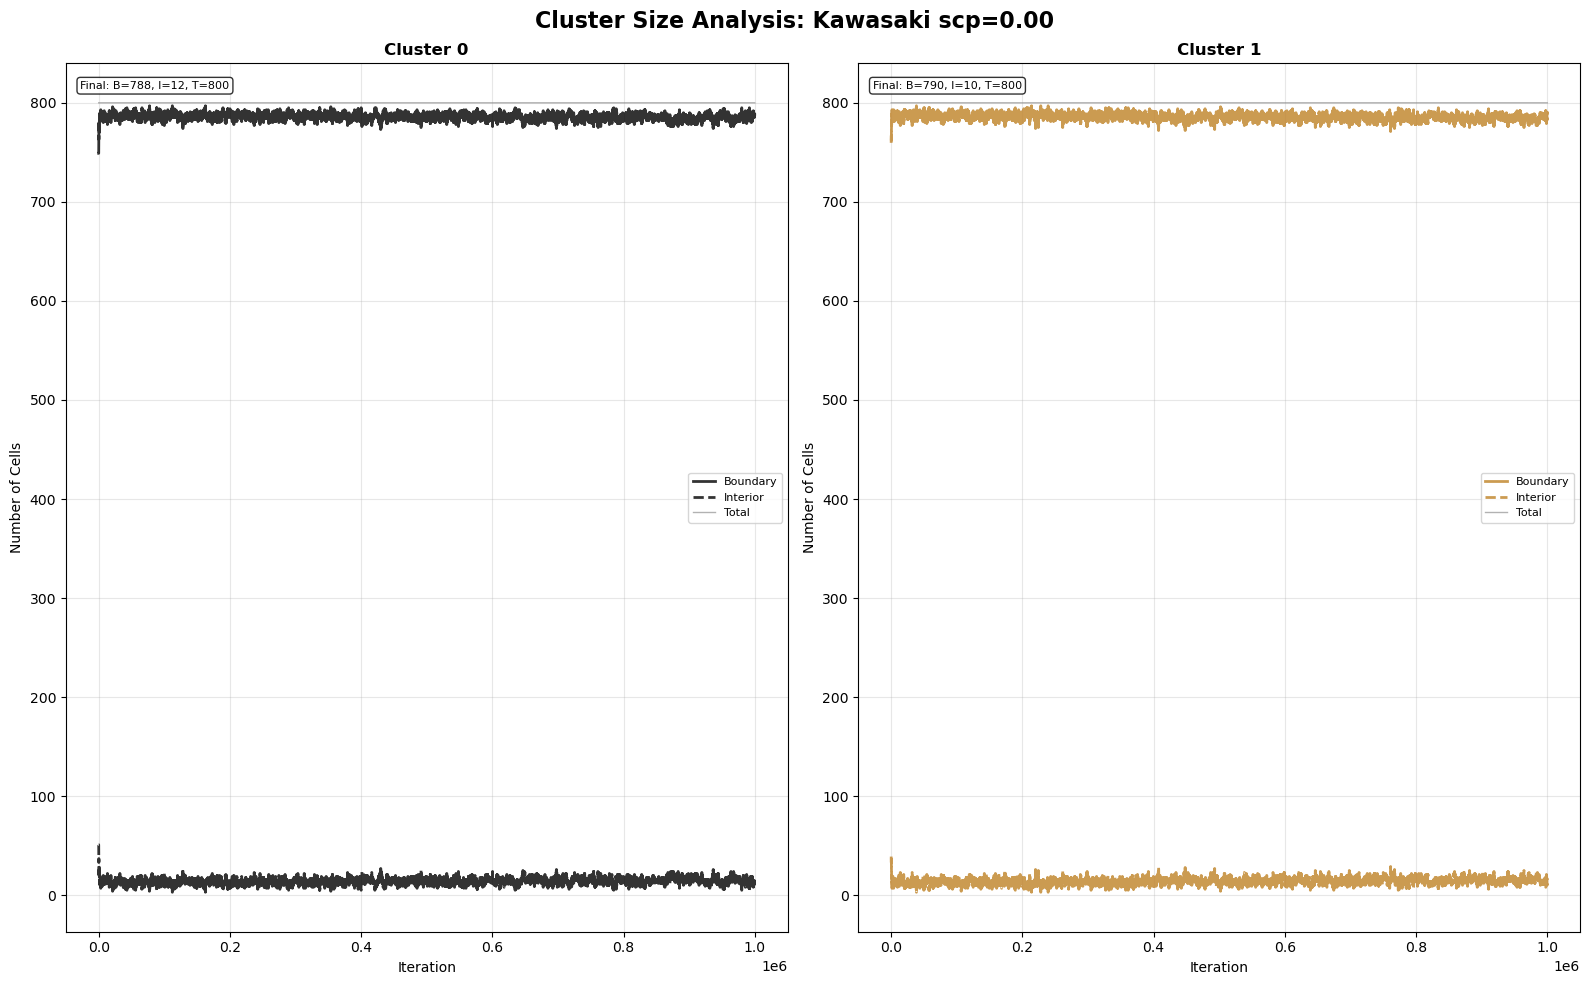


📈 Summary for Kawasaki scp=0.00:
   Total clusters: 2
   Cluster 0: Final B=788, I=12 | Avg B=785.9, I=14.1
   Cluster 1: Final B=790, I=10 | Avg B=785.9, I=14.1

🔍 Delayed Rejection Method Comparison:
   Analyzing 2 files



--- Cluster Size Analysis Complete ---

--- Starting Cluster Size Analysis for 2 files ---
📊 Processing BJ=-0.44_DR_1_tol0.50_scp0.50.csv: Found 3 clusters


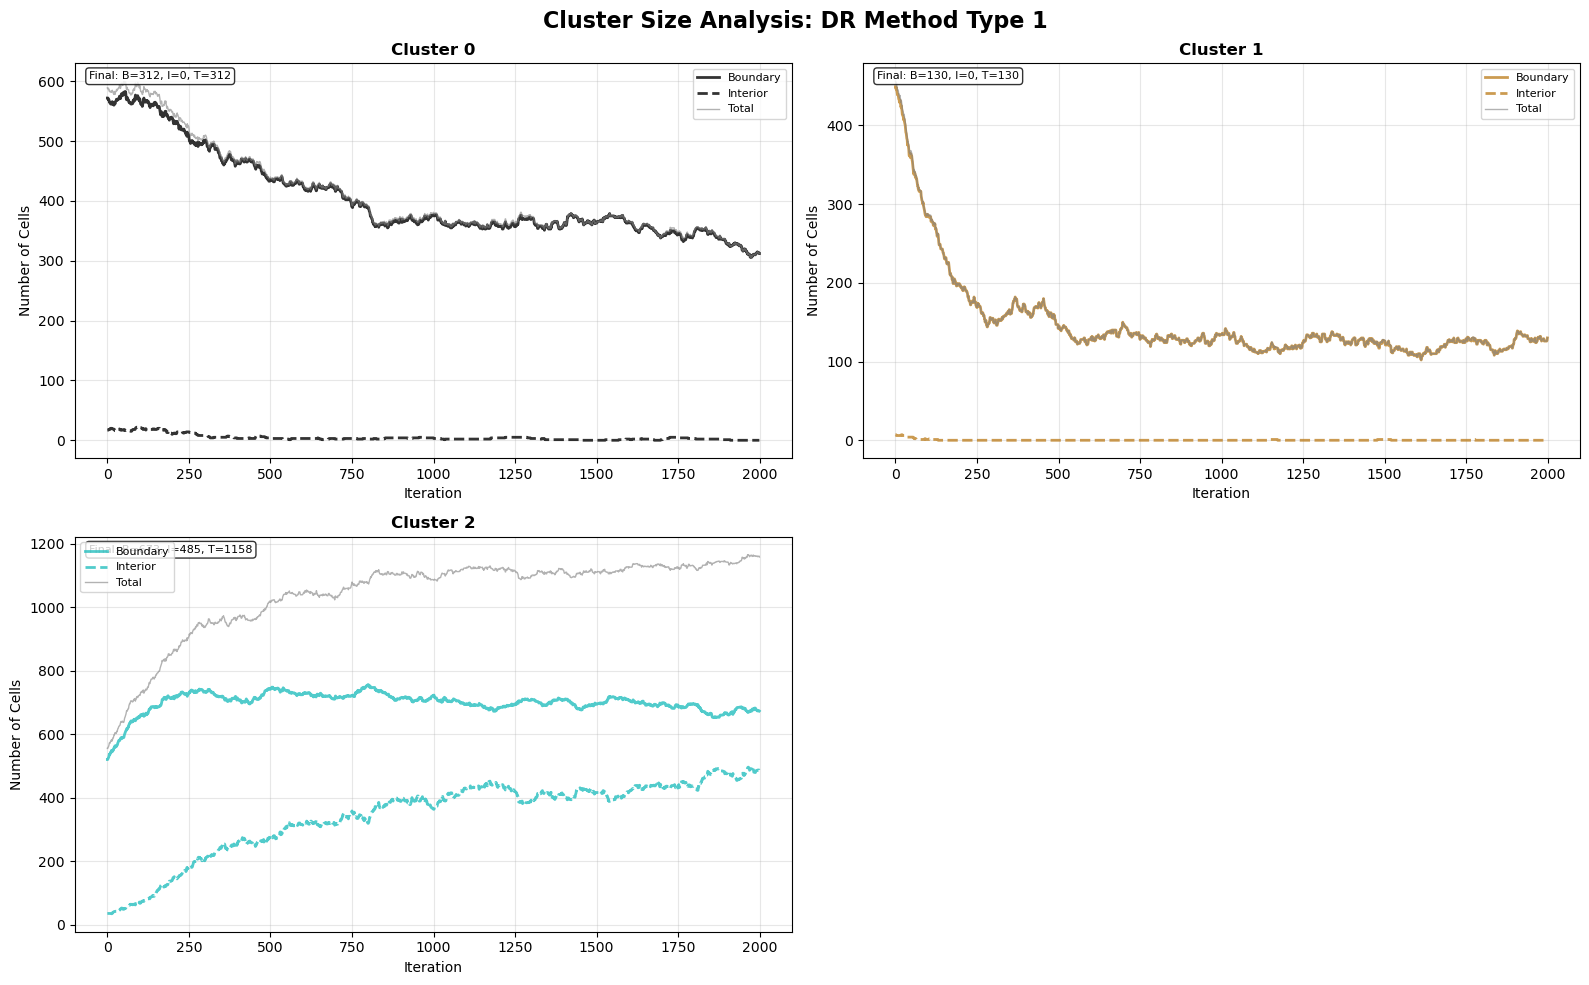


📈 Summary for DR Method Type 1:
   Total clusters: 3
   Cluster 0: Final B=312, I=0 | Avg B=405.1, I=4.5
   Cluster 1: Final B=130, I=0 | Avg B=148.7, I=0.2
   Cluster 2: Final B=673, I=485 | Avg B=699.5, I=341.9


📊 Processing BJ=-0.44_DR_2_tol0.50_scp0.50.csv: Found 5 clusters


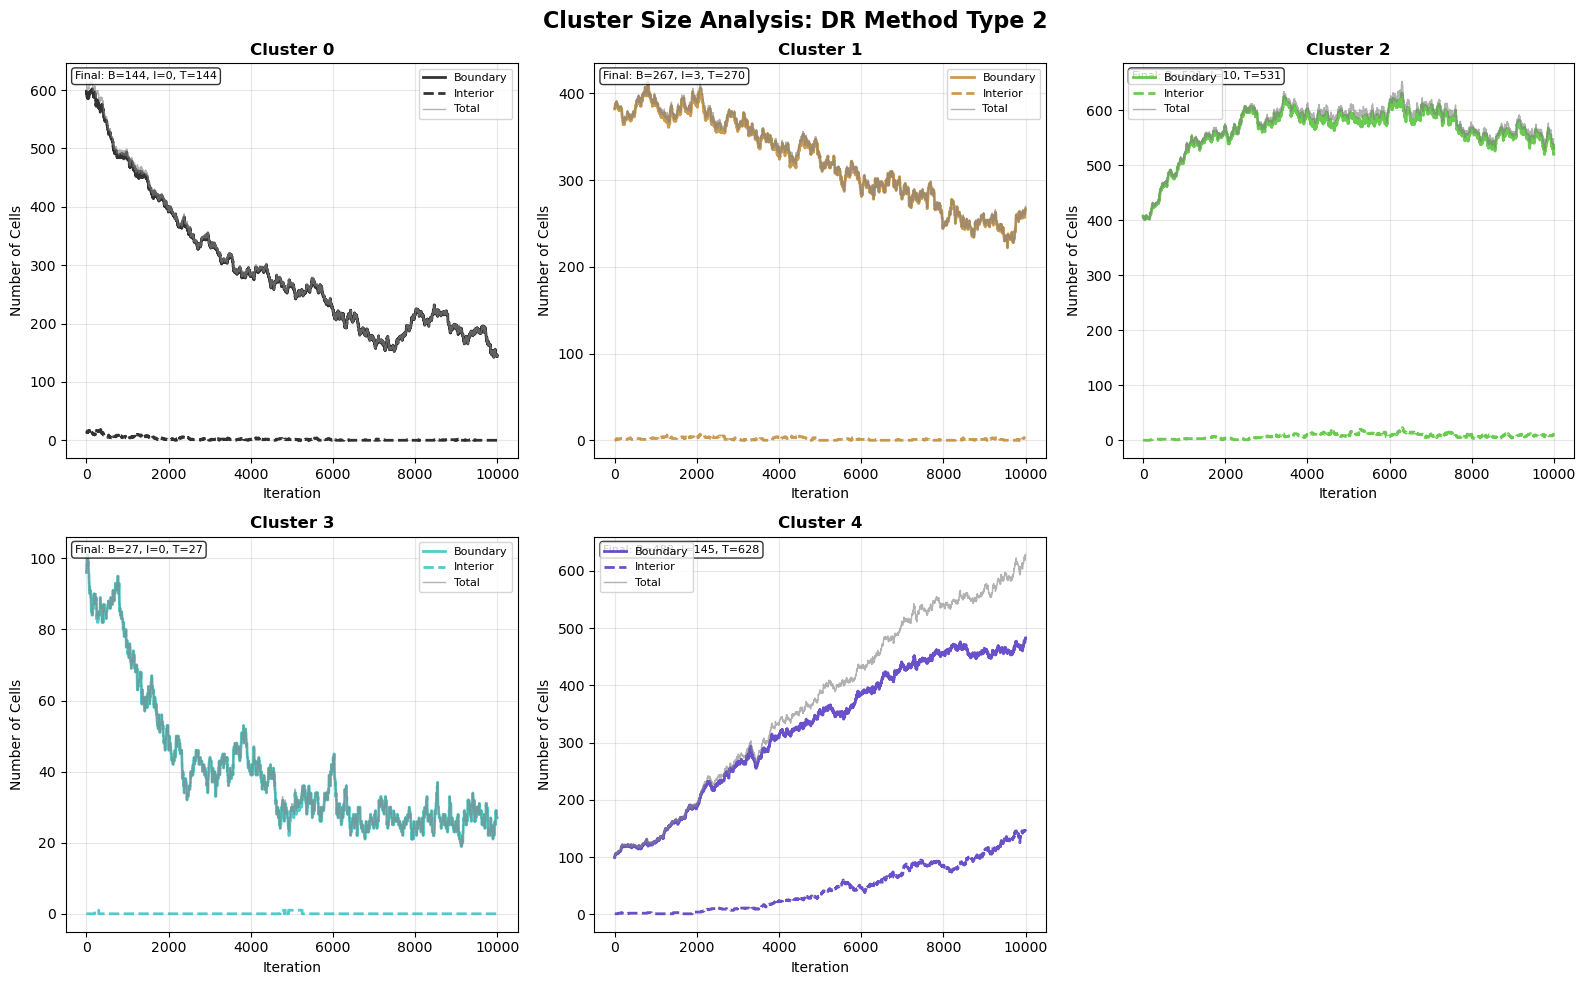


📈 Summary for DR Method Type 2:
   Total clusters: 5
   Cluster 0: Final B=144, I=0 | Avg B=293.5, I=2.2
   Cluster 1: Final B=267, I=3 | Avg B=320.8, I=1.5
   Cluster 2: Final B=521, I=10 | Avg B=562.3, I=7.6
   Cluster 3: Final B=27, I=0 | Avg B=40.7, I=0.1
   Cluster 4: Final B=483, I=145 | Avg B=325.3, I=46.0

📚 USAGE GUIDE:
1. batch_cluster_analysis('file1', 'file2', ...) - Simple analysis of multiple files
2. analyze_cluster_sizes(csv_files, table_labels=labels, curve_colours=colors) - Custom analysis
3. The module automatically detects the number of clusters in each file
4. Each file gets its own chart showing all clusters with boundary/interior/total sizes
5. Files can have different numbers of clusters - the module adapts automatically



--- Cluster Size Analysis Complete ---


In [43]:
# ---------------------------------------------------------------------
# 5. Advanced Cluster Analysis Examples
# ---------------------------------------------------------------------

print("=== Example 2: Advanced Cluster Analysis with Custom Colors ===")

# Example 2: Custom analysis with specific colors and labels
def custom_cluster_analysis():
    """Example showing how to use analyze_cluster_sizes with custom parameters"""
    
    # Define files and their properties
    analysis_configs = [
        {
            "files": ["BJ=-0.44_Kawasaki_0_tol0.00_scp0.50", "BJ=-0.44_Kawasaki_0_tol0.00_scp0.00"],
            "colors": ["#ff4444", "#ff8888"], 
            "labels": ["Kawasaki scp=0.50", "Kawasaki scp=0.00"],
            "title": "Kawasaki Method Comparison"
        },
        {
            "files": ["BJ=-0.44_DR_1_tol0.50_scp0.50", "BJ=-0.44_DR_2_tol0.50_scp0.50"],
            "colors": ["#4444ff", "#8888ff"],
            "labels": ["DR Method Type 1", "DR Method Type 2"],  
            "title": "Delayed Rejection Method Comparison"
        }
    ]
    
    for config in analysis_configs:
        existing_config_files = [f for f in config["files"] if Path(f"{f}.csv").is_file()]
        
        if existing_config_files:
            print(f"\n🔍 {config['title']}:")
            print(f"   Analyzing {len(existing_config_files)} files")
            
            csv_files = [f"{f}.csv" for f in existing_config_files]
            labels = [config["labels"][i] for i, f in enumerate(config["files"]) if f in existing_config_files]
            colors = [config["colors"][i] for i, f in enumerate(config["files"]) if f in existing_config_files]
            
            analyze_cluster_sizes(
                csv_files,
                table_labels=labels,
                curve_colours=colors
            )
        else:
            print(f"\n⚠️  {config['title']}: No files found")

# Run custom analysis
custom_cluster_analysis()

print("\n" + "="*60)
print("📚 USAGE GUIDE:")
print("1. batch_cluster_analysis('file1', 'file2', ...) - Simple analysis of multiple files")
print("2. analyze_cluster_sizes(csv_files, table_labels=labels, curve_colours=colors) - Custom analysis")
print("3. The module automatically detects the number of clusters in each file")
print("4. Each file gets its own chart showing all clusters with boundary/interior/total sizes")
print("5. Files can have different numbers of clusters - the module adapts automatically")
print("="*60)


In [44]:
# ---------------------------------------------------------------------
# 2. compare_runs – energy plots, slopes, convergence table
# ---------------------------------------------------------------------
def compare_runs(csv_files,*,table_labels,curve_colours,
                 legend_labels,legend_colours,
                 title="Energy & Convergence Analysis"):

    plt.rcParams.update({'font.size':13})

    # --- Figure 1: Original Energy Plots ---
    fig1 = plt.figure(figsize=(20, 15))
    gs1 = fig1.add_gridspec(3, 3, height_ratios=[1, 1, 1], hspace=0.4)

    ax_raw = fig1.add_subplot(gs1[0,:])
    ax_E,ax_dE,ax_simple = fig1.add_subplot(gs1[1,0]), fig1.add_subplot(gs1[1,1]), fig1.add_subplot(gs1[1,2])
    ax_slope = fig1.add_subplot(gs1[2,:])

    fig1.suptitle(title + " - Energy Plots (Full Data)", fontsize=22, fontweight="bold", y=0.95)

    lengths = [len(pd.read_csv(f)) for f in csv_files if Path(f).is_file()]
    if not lengths: return
    W = max(50,min(1000,min(lengths)//10))
    thr = 1e-4
    streak = max(3,min(10,W//100))
    max_steps_full = 0 # Max steps for full data plots

    T_full_data = {k:[] for k in("run","Efin","conv_iter","conv_E",
                                  "norm_Efin","norm_conv_iter","norm_conv_E", "acceptance_rate")}
    all_filtered_energies = {} # Dictionary to store energies and weights for each run

    # Loop for plotting full data
    for fp, lbl_tbl, col, lbl_leg in zip(csv_files, table_labels, curve_colours,
                                         itertools.cycle(legend_labels or [None])):
        p = Path(fp)
        if not p.is_file(): continue
        try:
            df = pd.read_csv(p)
            if "Energy" not in df.columns: continue

            steps = np.arange(len(df))
            max_steps_full = max(max_steps_full,len(df))
            E = df["Energy"].ffill().bfill()
            ax_raw.plot(steps,E,lw=1,color=col,alpha=0.5,label=lbl_leg)

            cum = E.expanding().mean()
            ax_E.plot(steps,cum,lw=2,color=col,alpha=0.7)
            
            # Simple energy plot with log x-axis (like row 1 but with log x)
            ax_simple.plot(steps,E,lw=1,color=col,alpha=0.7,label=lbl_leg)

            if "Total_Acceptances" in df.columns and "Move_Attempts" in df.columns:
                acceptance_rate = (df["Total_Acceptances"].iloc[-1] * 100.0 / df["Move_Attempts"].iloc[-1]) if df["Move_Attempts"].iloc[-1] > 0 else 0.0
            else:
                acceptance_rate = float('nan')

            wn = None
            weights = None
            if "Norm" in df.columns:
                N_norm = df["Norm"].replace([np.inf,-np.inf,0],np.nan).ffill().bfill()
                #eff = (1-N_norm)/N_norm + 1
                eff = (1-N_norm)*0/N_norm + 1 # This line seems to set eff to 1 always if N_norm is a number. Is this intended?
                wn = (E*eff).cumsum()/eff.cumsum()
                weights = eff  # Store weights for histogram
                ax_E.plot(steps,wn,lw=2,ls="--",color=col,alpha=0.7)

            stride = max(1,len(steps)//1000)
            ax_dE.scatter(steps[1::stride],np.abs(np.diff(cum))[::stride],
                          s=10,alpha=.7,color=col)
            conv = nconv = None
            if len(cum)>=2*W:
                idx = np.arange(0,len(cum)-W,W)
                sl = np.array([(cum[i+W]-cum[i])/W for i in idx])
                ax_slope.scatter(idx+W/2,np.abs(sl),s=24,alpha=.8,color=col)
                conv = next((int(idx[i]) for i in range(len(sl)-streak+1)
                             if np.all(np.abs(sl[i:i+streak])<thr)),None)
            if wn is not None and len(wn)>=2*W:
                idxN = np.arange(0,len(wn)-W,W)
                slN = np.array([(wn[i+W]-wn[i])/W for i in idxN])
                ax_slope.scatter(idxN+W/2,np.abs(slN),
                                  marker="x",s=26,alpha=.8,color=col)
                nconv = next((int(idxN[i]) for i in range(len(slN)-streak+1)
                              if np.all(np.abs(slN[i:i+streak])<thr)),None)

            # Store filtered energies with their color and weights
            start_index_for_80_percent = int(0.2 * len(df))
            all_filtered_energies[lbl_tbl] = {
                'energies': df["Energy"].iloc[start_index_for_80_percent:].tolist(),
                'color': col,
                'weights': weights.iloc[start_index_for_80_percent:].tolist() if weights is not None else None,
                'steps': steps[start_index_for_80_percent:].tolist(),
                'cum': cum.iloc[start_index_for_80_percent:].tolist(),
                'wn': wn.iloc[start_index_for_80_percent:].tolist() if wn is not None else None
            }

            # Populate table data for full run
            T_full_data["run"].append(lbl_tbl)
            T_full_data["Efin"].append(f"{cum.iloc[-1]:.4g}")
            T_full_data["conv_iter"].append(conv if conv is not None else "¬conv")
            T_full_data["conv_E"].append(f"{cum[conv]:.4g}" if conv is not None else "N/A")
            T_full_data["acceptance_rate"].append(f"{acceptance_rate:.2f}%" if not np.isnan(acceptance_rate) else "N/A")
            if wn is not None:
                T_full_data["norm_Efin"].append(f"{wn.iloc[-1]:.4g}")
                T_full_data["norm_conv_iter"].append(nconv if nconv is not None else "N/A")
                T_full_data["norm_conv_E"].append(f"{wn[nconv]:.4g}" if nconv is not None else "N/A")
            else:
                T_full_data["norm_Efin"].append("N/A")
                T_full_data["norm_conv_iter"].append("N/A")
                T_full_data["norm_conv_E"].append("N/A")

        except Exception as e: print(f"[warn] {p.name}: {e}", file=sys.stderr)

    # Cosmetics for Figure 1 axes (Full Data)
    ax_raw.set(xlabel="step",ylabel="E"); ax_raw.grid(ls=":")
    if any(legend_labels):
        ax_raw.legend(fontsize=12, handleheight=8, handlelength=8)
        for legline in ax_raw.get_legend().get_lines():
            legline.set_linewidth(6.0)

    ax_E.set(xscale="log",xlabel="step",ylabel="⟨E⟩"); ax_E.grid(ls=":")

    ax_dE.set(xscale="log",yscale="log",xlim=(1,max_steps_full),
              xlabel="step",ylabel="|Δ⟨E⟩|"); ax_dE.grid(ls=":")

    ax_simple.set(xscale="log",xlim=(1,max_steps_full),xlabel="step",ylabel="E"); ax_simple.grid(ls=":")
    if any(legend_labels):
        ax_simple.legend(fontsize=10, loc='best')

    ax_slope.set(xscale="log",yscale="log",
                  xlabel="step",ylabel=f"|slope| (W={W})"); ax_slope.grid(ls=":")

    plt.tight_layout()
    fig1.savefig("energy_plots_full_data.png", dpi=300, bbox_inches="tight",
                  pad_inches=0.5, transparent=False)
    plt.show()

    # --- Figure 2: Original Convergence Table ---
    num_rows_full = len(T_full_data["run"])
    row_height_full = 0.5
    fig_height_full = max(8.5, 2 + (num_rows_full * row_height_full))

    fig2 = plt.figure(figsize=(20, fig_height_full))
    ax_tbl = fig2.add_subplot(111)
    ax_tbl.axis("off")

    fig2.suptitle(title + " - Convergence Data (Full Data)", fontsize=22, fontweight="bold", y=0.95)

    cell_text_full = list(zip(T_full_data["run"],T_full_data["Efin"],T_full_data["conv_iter"],T_full_data["conv_E"],
                              T_full_data["norm_Efin"],T_full_data["norm_conv_iter"],T_full_data["norm_conv_E"],
                              T_full_data["acceptance_rate"]))

    col_labels_full = ["run","final E","conv iter","conv E",
                       "Norm Efin","Norm conv iter","Norm Norm conv E",
                       "Accept Rate"]

    cell_scale_full = min(2.0, 20/num_rows_full)

    tbl_full = ax_tbl.table(cellText=cell_text_full,
                            colLabels=col_labels_full,
                            loc="center",
                            cellLoc="center")

    font_size_full = min(12, 160/num_rows_full)
    tbl_full.auto_set_font_size(False)
    tbl_full.set_fontsize(font_size_full)
    tbl_full.scale(cell_scale_full, cell_scale_full * 1.2)

    for cell in tbl_full._cells.values():
        cell.set_edgecolor('black')
        cell.set_facecolor('white')
        cell.set_alpha(0.8)

    plt.tight_layout()
    fig2.savefig("convergence_table_full_data.png", dpi=300, bbox_inches="tight",
                  pad_inches=0.5, transparent=False)
    plt.show()

    # --- Figure 3: Filtered Data Plots ---
    if all_filtered_energies:
        fig3 = plt.figure(figsize=(20, 17))
        gs3 = fig3.add_gridspec(3, 3, height_ratios=[1, 1, 1], hspace=0.4)

        ax_raw_f = fig3.add_subplot(gs3[0,:])
        ax_E_f,ax_dE_f,ax_simple_f = fig3.add_subplot(gs3[1,0]), fig3.add_subplot(gs3[1,1]), fig3.add_subplot(gs3[1,2])
        ax_slope_f = fig3.add_subplot(gs3[2,:])

        fig3.suptitle(title + " - Energy Plots (Feed-in Removed)", fontsize=22, fontweight="bold", y=0.95)

        max_steps_filtered = 0
        T_filtered_data = {k:[] for k in("run","Efin","conv_iter","conv_E",
                                         "norm_Efin","norm_conv_iter","norm_conv_E",
                                         "acceptance_rate")}

        for run_name, run_data in all_filtered_energies.items():
            steps = run_data['steps']
            max_steps_filtered = max(max_steps_filtered, len(steps))
            
            # Plot raw energies
            ax_raw_f.plot(steps, run_data['energies'], lw=1, color=run_data['color'], alpha=0.5, label=run_name)
            
            # Plot cumulative average
            ax_E_f.plot(steps, run_data['cum'], lw=2, color=run_data['color'], alpha=0.7)
            
            if run_data['wn'] is not None:
                ax_E_f.plot(steps, run_data['wn'], lw=2, ls="--", color=run_data['color'], alpha=0.7)

            # Plot simple energy with log x-axis (filtered data)
            ax_simple_f.plot(steps, run_data['energies'], lw=1, color=run_data['color'], alpha=0.7, label=run_name)

            # Plot energy differences
            stride = max(1, len(steps)//1000)
            cum_array = np.array(run_data['cum'])
            ax_dE_f.scatter(steps[1::stride], np.abs(np.diff(cum_array))[::stride],
                            s=10, alpha=.7, color=run_data['color'])

            # Plot slopes
            if len(cum_array) >= 2*W:
                idx = np.arange(0, len(cum_array)-W, W)
                sl = np.array([(cum_array[i+W]-cum_array[i])/W for i in idx])
                ax_slope_f.scatter(idx+W/2, np.abs(sl), s=24, alpha=.8, color=run_data['color'])
                conv = next((int(idx[i]) for i in range(len(sl)-streak+1)
                             if np.all(np.abs(sl[i:i+streak])<thr)), None)
            else:
                conv = None

            # Populate filtered data table
            T_filtered_data["run"].append(run_name)
            T_filtered_data["Efin"].append(f"{run_data['cum'][-1]:.4g}")
            T_filtered_data["conv_iter"].append(conv if conv is not None else "¬conv")
            T_filtered_data["conv_E"].append(f"{run_data['cum'][conv]:.4g}" if conv is not None else "N/A")
            
            if run_data['wn'] is not None:
                T_filtered_data["norm_Efin"].append(f"{run_data['wn'][-1]:.4g}")
                T_filtered_data["norm_conv_iter"].append("N/A")  # Simplified for filtered data
                T_filtered_data["norm_conv_E"].append("N/A")    # Simplified for filtered data
            else:
                T_filtered_data["norm_Efin"].append("N/A")
                T_filtered_data["norm_conv_iter"].append("N/A")
                T_filtered_data["norm_conv_E"].append("N/A")
            
            # Calculate acceptance rate for filtered data
            T_filtered_data["acceptance_rate"].append(T_full_data["acceptance_rate"][T_full_data["run"].index(run_name)])

        # Cosmetics for Figure 3 axes (Filtered Data)
        ax_raw_f.set(xlabel="step", ylabel="E")
        ax_raw_f.grid(ls=":")
        if any(legend_labels):
            ax_raw_f.legend(fontsize=12, handleheight=8, handlelength=8)
            for legline in ax_raw_f.get_legend().get_lines():
                legline.set_linewidth(6.0)

        ax_E_f.set(xscale="log", xlabel="step", ylabel="⟨E⟩")
        ax_E_f.grid(ls=":")

        # Fix x-axis alignment - use proper range for filtered data
        min_step_filtered = min([min(run_data['steps']) for run_data in all_filtered_energies.values()])
        ax_dE_f.set(xscale="log", yscale="log", xlim=(min_step_filtered, max_steps_filtered),
                    xlabel="step", ylabel="|Δ⟨E⟩|")
        ax_dE_f.grid(ls=":")

        ax_simple_f.set(xscale="log", xlim=(min_step_filtered, max_steps_filtered), xlabel="step", ylabel="E")
        ax_simple_f.grid(ls=":")
        if any(legend_labels):
            ax_simple_f.legend(fontsize=10, loc='best')

        ax_slope_f.set(xscale="log", yscale="log",
                        xlabel="step", ylabel=f"|slope| (W={W})")
        ax_slope_f.grid(ls=":")

        plt.tight_layout()
        fig3.savefig("energy_plots_filtered_data.png", dpi=300, bbox_inches="tight",
                      pad_inches=0.5, transparent=False)
        plt.show()

        # --- Figure 4: Filtered Data Convergence Table ---
        num_rows_filtered = len(T_filtered_data["run"])
        row_height_filtered = 0.5
        fig_height_filtered = max(8.5, 2 + (num_rows_filtered * row_height_filtered))

        fig4 = plt.figure(figsize=(20, fig_height_filtered))
        ax_tbl_f = fig4.add_subplot(111)
        ax_tbl_f.axis("off")

        fig4.suptitle(title + " - Convergence Data (Feed-in Removed)", fontsize=22, fontweight="bold", y=0.95)

        cell_text_filtered = list(zip(T_filtered_data["run"],T_filtered_data["Efin"],
                                      T_filtered_data["conv_iter"],T_filtered_data["conv_E"],
                                      T_filtered_data["norm_Efin"],T_filtered_data["norm_conv_iter"],
                                      T_filtered_data["norm_conv_E"],T_filtered_data["acceptance_rate"]))

        cell_scale_filtered = min(2.0, 20/num_rows_filtered)

        tbl_filtered = ax_tbl_f.table(cellText=cell_text_filtered,
                                      colLabels=col_labels_full,
                                      loc="center",
                                      cellLoc="center")

        font_size_filtered = min(12, 160/num_rows_filtered)
        tbl_filtered.auto_set_font_size(False)
        tbl_filtered.set_fontsize(font_size_filtered)
        tbl_filtered.scale(cell_scale_filtered, cell_scale_filtered * 1.2)

        for cell in tbl_filtered._cells.values():
            cell.set_edgecolor('black')
            cell.set_facecolor('white')
            cell.set_alpha(0.8)

        plt.tight_layout()
        fig4.savefig("convergence_table_filtered_data.png", dpi=300, bbox_inches="tight",
                      pad_inches=0.5, transparent=False)
        plt.show()

        # --- Figure 5: PDF Plot (Feed-in Removed) ---
        fig5 = plt.figure(figsize=(10, 7))
        ax_pdf = fig5.add_subplot(111)
        fig5.suptitle(title + " - PDF of Raw Energy (Feed-in Removed)", fontsize=18, fontweight="bold")

        # Create bins from min to max energy
        all_energies = [e for run in all_filtered_energies.values() for e in run['energies']]
        max_e = max(all_energies)
        min_e = min(all_energies)
        bin_start = math.floor(min_e/500) * 500 - 5
        bin_end = math.floor(max_e/500) * 500 - 5
        bins = np.arange(bin_start, bin_end + 500, 500)

        # Plot weighted histogram for each run
        for run_name, run_data in all_filtered_energies.items():
            weights = run_data['weights'] if run_data['weights'] is not None else None
            ax_pdf.hist(run_data['energies'], bins=bins, density=True, alpha=0.5,
                        weights=weights, color=run_data['color'], 
                        label=run_name, edgecolor='black')

        ax_pdf.set_xlabel("Energy")
        ax_pdf.set_ylabel("Probability Density")
        ax_pdf.grid(ls=":")
        ax_pdf.legend(fontsize=8)
        plt.tight_layout()
        fig5.savefig("energy_pdf_feed_in_removed.png", dpi=300, bbox_inches="tight",
                      pad_inches=0.5, transparent=False)
        plt.show()

In [45]:
# ---------------------------------------------------------------------
# 3. plot_grid (Modified for static plots; animation uses inline logic)
# ---------------------------------------------------------------------
def plot_grid(cfg_df: pd.DataFrame, *, title: str = None, figsize=(8, 8),
              ax=None, save_path: Path = None, grid_size: int = None):
    """
    Plots the grid configuration from GridConfig CSV data.
    Expected CSV format (as saved by Sim.cpp):
    - Header: x,y,species,cluster_id,cell_type
    - cell_type values: "BOUNDARY", "INTERIOR", "ANY"
    - species values: 0, 1 (integers)
    """
    # Validate input data
    if cfg_df.empty:
        print("Warning: Empty DataFrame provided to plot_grid", file=sys.stderr)
        fig, ax_empty = plt.subplots(figsize=figsize)
        ax_empty.text(0.5, 0.5, "Empty Grid (No Config)", ha='center', va='center', 
                     transform=ax_empty.transAxes, fontsize=16)
        ax_empty.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[])
        if save_path:
            fig.savefig(save_path, dpi=250, bbox_inches="tight")
            plt.close(fig)
        else:
            plt.show()
        return
    
    # Validate required columns
    required_cols = ["x", "y", "species", "cluster_id", "cell_type"]
    missing_cols = [col for col in required_cols if col not in cfg_df.columns]
    if missing_cols:
        print(f"Error: Missing required columns in GridConfig: {missing_cols}", file=sys.stderr)
        print(f"Available columns: {list(cfg_df.columns)}", file=sys.stderr)
        return
    
    # Determine grid size
    if grid_size is None:
        N = int(max(cfg_df["x"].max(), cfg_df["y"].max()) + 1) if not cfg_df.empty else 0
    else:
        N = grid_size
    
    print(f"Debug: Grid size determined as {N}x{N} ({len(cfg_df)} cells)", file=sys.stderr)
    
    # Create figure
    fig, ax_local = plt.subplots(1, 1, figsize=figsize)
    ax_local.set(xlim=(-0.5, N-0.5), ylim=(-0.5, N-0.5), aspect="equal", xticks=[], yticks=[])
    ax_local.set_title(title or "Grid Configuration", fontweight="bold", fontsize=14)
    
    # Use a copy to avoid modifying original data
    df_display = cfg_df.copy()
    
    # Get unique cluster IDs for color mapping
    unique_clusters = sorted(df_display["cluster_id"].unique())
    cluster_colors = get_distinct_colors(len(unique_clusters))
    cluster_color_map = {cluster_id: cluster_colors[i] for i, cluster_id in enumerate(unique_clusters)}
    
    # Draw grid cells
    for _, r in df_display.iterrows():
        # Determine cell color based on species
        if r["species"] == 0:
            base_color = "#d62728"  # Red for species 0
        elif r["species"] == 1:  
            base_color = "#1f77b4"  # Blue for species 1
        else:
            base_color = "#808080"  # Gray for unknown species
        
        # Determine transparency based on cell type
        if r["cell_type"] == "INTERIOR":
            alpha = 0.4
        elif r["cell_type"] == "BOUNDARY":
            alpha = 0.8
        else:  # "ANY" or other
            alpha = 0.6
        
        # Create rectangle for the cell
        rect = plt.Rectangle((r["x"]-0.4, r["y"]-0.4), 0.8, 0.8,
                           facecolor=base_color, alpha=alpha, 
                           edgecolor='black', linewidth=0.5)
        ax_local.add_patch(rect)
        
        # Add cluster ID text in the center of the cell
        txt = ax_local.text(r["x"], r["y"], str(r["cluster_id"]),
                          ha="center", va="center", fontsize=8, 
                          color='white', weight='bold')
        ax_local.add_artist(txt)
    
    # Add legend
    legend_elements = [
        Patch(facecolor="#d62728", alpha=0.8, label='Species 0 (Boundary)'),
        Patch(facecolor="#d62728", alpha=0.4, label='Species 0 (Interior)'),
        Patch(facecolor="#1f77b4", alpha=0.8, label='Species 1 (Boundary)'),
        Patch(facecolor="#1f77b4", alpha=0.4, label='Species 1 (Interior)')
    ]
    ax_local.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    
    # Add grid lines for better visualization
    for i in range(N+1):
        ax_local.axhline(i-0.5, color='gray', linewidth=0.3, alpha=0.5)
        ax_local.axvline(i-0.5, color='gray', linewidth=0.3, alpha=0.5)
    
    # Add cluster statistics as text
    cluster_stats = []
    for cluster_id in unique_clusters:
        cluster_cells = df_display[df_display["cluster_id"] == cluster_id]
        boundary_count = len(cluster_cells[cluster_cells["cell_type"] == "BOUNDARY"])
        interior_count = len(cluster_cells[cluster_cells["cell_type"] == "INTERIOR"])
        total_count = len(cluster_cells)
        cluster_stats.append(f"Cluster {cluster_id}: B={boundary_count}, I={interior_count}, Total={total_count}")
    
    stats_text = "\n".join(cluster_stats)
    ax_local.text(1.02, 0.5, stats_text, transform=ax_local.transAxes, 
                 fontsize=9, verticalalignment='center',
                 bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    
    # Handle saving and displaying  
    if save_path:
        fig.savefig(save_path, dpi=250, bbox_inches="tight")
        print(f"Grid plot saved to: {save_path}", file=sys.stderr)
    
    # Always display the plot visually in addition to saving
    plt.show()

In [46]:
# ---------------------------------------------------------------------
# 6. driver
# ---------------------------------------------------------------------
def run_visualizations(*,
                         BJ:str,
                         include_kawasaki:bool=True,
                         base_variants:List[str]|None=None,
                         signifiers:List[List[str]]|None=None,
                         cluster_types:List[str]|None=None,
                         plot_energy=True,plot_grids=False,plot_moves=False,plot_clusters=True):
    """
    Complex combinatoric workflow for generating filenames and visualizations.
    
    Args:
        BJ (str): Beta*J parameter for filename generation
        include_kawasaki (bool): Whether to include Kawasaki algorithm files
        base_variants (List[str]): Base algorithm variants (e.g., ["NewMC", "DR"])
        signifiers (List[List[str]]): Parameter combinations (e.g., [["tol0.01"], ["scp0.50"]])
        cluster_types (List[str]): Cluster type variants (e.g., ["1", "2"])
        plot_energy (bool): Whether to plot energy and convergence analysis
        plot_grids (bool): Whether to plot static grid configurations
        plot_moves (bool): Whether to plot move statistics (not yet implemented)
        plot_clusters (bool): Whether to plot cluster size analysis
    """
    base_variants=base_variants or [""]
    signifiers   =signifiers    or [[""]]
    cluster_types=cluster_types or ["1"]

    csv_files,tbl,col,leg,leg_col,expand = build_filenames(
        BJ=BJ, include_kawasaki=include_kawasaki,
        base_variants=base_variants, signifiers=signifiers, cluster_types=cluster_types)

    if plot_energy:
        compare_runs(csv_files=csv_files, table_labels=tbl, curve_colours=col,
                     legend_labels=leg, legend_colours=leg_col)
    
    if plot_clusters:
        print("\n--- Running Cluster Analysis for Complex Batch ---", file=sys.stderr)
        analyze_cluster_sizes(csv_files=csv_files, table_labels=tbl, curve_colours=col)
    
    if plot_grids:
        print("\n--- Running Static Grid Plots for Simple Batch ---", file=sys.stderr)
        for fp, lab in zip(csv_files, tbl):
            main_csv_file = Path(fp)
            grid_cfg_file = main_csv_file.with_name(main_csv_file.stem + "_GridConfig.csv")
            
            df_grid_to_plot = pd.DataFrame()
            if grid_cfg_file.exists():
                print(f"Debug: Plotting static grid from {grid_cfg_file}", file=sys.stderr)
                try:
                    df_grid_to_plot = pd.read_csv(grid_cfg_file)
                    # For static grid plots, we only care about the final state
                    # Here, plot_grid is called without 'ax', so it will create its own figure.
                    plot_grid(df_grid_to_plot, title=f"{lab} (Static Grid)", save_path=grid_cfg_file.with_suffix(".png"))
                except Exception as e:
                    print(f"Error loading or plotting static grid from {grid_cfg_file}: {e}", file=sys.stderr)
            elif main_csv_file.exists():
                print(f"Debug: Plotting static grid from main CSV {main_csv_file} (fallback)", file=sys.stderr)
                try:
                    dtype_mapping = {
                        "PossiblyChanged": str, "ProposedAtoms": str, "AcceptedAtoms": str,
                        "AcceptedPossiblyChanged": str, "GridConfigStarting": str, "GridConfigPotential": str
                    }
                    df_sim_last_row = pd.read_csv(main_csv_file, dtype=dtype_mapping).tail(1)
                    if not df_sim_last_row.empty:
                        grid_config_str = None
                        N_for_static = 0

                        # Determine N from the first available config string
                        for _, row in df_sim_last_row.iterrows():
                            potential_str = str(row.get("GridConfigPotential", "")).strip('"').strip("'")
                            starting_str = str(row.get("GridConfigStarting", "")).strip('"').strip("'")

                            if potential_str:
                                num_cells = len(potential_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Potential GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = potential_str
                                title_suffix = "(from Final Potential GridConfig in Main CSV)"
                                break
                            elif starting_str:
                                num_cells = len(starting_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Starting GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = starting_str
                                title_suffix = "(from Final Starting GridConfig in Main CSV)"
                                break
                        
                        if grid_config_str and N_for_static > 0:
                            df_grid_to_plot = parse_grid_config_string(grid_config_str, N_for_static)
                            if not df_grid_to_plot.empty:
                                plot_grid(df_grid_to_plot, title=f"{lab} {title_suffix}",
                                          save_path=main_csv_file.with_suffix(".static_grid.png"),
                                          grid_size=N_for_static)
                            else:
                                print(f"Warning: GridConfig column empty or malformed in {main_csv_file.name} for static plot.", file=sys.stderr)
                        else:
                            print(f"Warning: Neither 'GridConfigPotential' nor 'GridConfigStarting' found/valid in {main_csv_file.name} for static plot.", file=sys.stderr)
                    else:
                        print(f"Warning: Main CSV file {main_csv_file.name} is empty for static plot.", file=sys.stderr)
                except Exception as e:
                    print(f"Error loading or plotting static grid from main CSV {main_csv_file}: {e}", file=sys.stderr)
            else:
                print(f"Grid config file and main CSV not found for static plot: {grid_cfg_file}", file=sys.stderr)

def simple_batch(*m_batch_filenames: List[str],
                    plot_energy: bool=True, plot_grids: bool=False, plot_clusters: bool=True):
    """
    Streamlined workflow for generating visualizations from a list of pre-configured filenames.
    Uses a simpler, distinct color scheme for plots.

    Args:
        m_batch_filenames (List[str]): List of base filenames (e.g., ["BJ=1.0_MC_1_tol0.01_scp0.05"]).
                                    The function will append ".csv" for main data and "_GridConfig.csv"
                                    for grid config files.
        plot_energy (bool): Whether to plot energy and convergence data.
        plot_grids (bool): Whether to plot static grid configurations.
        plot_clusters (bool): Whether to plot cluster size analysis.
    """
    csv_files = [f"{bf}.csv" for bf in m_batch_filenames]
    table_labels = m_batch_filenames # Use base filename as label
    curve_colours = get_distinct_colors(len(m_batch_filenames))
    legend_labels = m_batch_filenames # Use base filename as label
    legend_colours = curve_colours

    if plot_energy:
        print("\n--- Running Energy Plots for Simple Batch ---", file=sys.stderr)
        compare_runs(csv_files=csv_files, table_labels=table_labels, curve_colours=curve_colours,
                     legend_labels=legend_labels, legend_colours=legend_colours,
                     title="Simple Batch Energy & Convergence Analysis")
    
    if plot_clusters:
        print("\n--- Running Cluster Analysis for Simple Batch ---", file=sys.stderr)
        analyze_cluster_sizes(csv_files=csv_files, table_labels=table_labels, curve_colours=curve_colours)
    
    if plot_grids:
        print("\n--- Running Static Grid Plots for Simple Batch ---", file=sys.stderr)
        for bf, lab in zip(m_batch_filenames, table_labels):
            main_csv_file = Path(f"{bf}.csv")
            grid_cfg_file = Path(f"{bf}_GridConfig.csv")
            
            df_grid_to_plot = pd.DataFrame()
            if grid_cfg_file.exists():
                print(f"Debug: Plotting static grid from {grid_cfg_file}", file=sys.stderr)
                try:
                    df_grid_to_plot = pd.read_csv(grid_cfg_file)
                    plot_grid(df_grid_to_plot, title=f"{lab} (Static Grid)", save_path=grid_cfg_file.with_suffix(".png"))
                except Exception as e:
                    print(f"Error loading or plotting static grid from {grid_cfg_file}: {e}", file=sys.stderr)
            elif main_csv_file.exists():
                print(f"Debug: Plotting static grid from main CSV {main_csv_file} (fallback)", file=sys.stderr)
                try:
                    dtype_mapping = {
                        "PossiblyChanged": str, "ProposedAtoms": str, "AcceptedAtoms": str,
                        "AcceptedPossiblyChanged": str, "GridConfigStarting": str, "GridConfigPotential": str
                    }
                    df_sim_last_row = pd.read_csv(main_csv_file, dtype=dtype_mapping).tail(1)
                    if not df_sim_last_row.empty:
                        grid_config_str = None
                        N_for_static = 0

                        # Determine N from the first available config string in the last row
                        for _, row in df_sim_last_row.iterrows(): # This loop will run once for the tail(1) row
                            potential_str = str(row.get("GridConfigPotential", "")).strip('"').strip("'")
                            starting_str = str(row.get("GridConfigStarting", "")).strip('"').strip("'")

                            if potential_str:
                                num_cells = len(potential_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Potential GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = potential_str
                                title_suffix = "(from Final Potential GridConfig in Main CSV)"
                                break
                            elif starting_str:
                                num_cells = len(starting_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Starting GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = starting_str
                                title_suffix = "(from Final Starting GridConfig in Main CSV)"
                                break
                        
                        if grid_config_str and N_for_static > 0:
                            df_grid_to_plot = parse_grid_config_string(grid_config_str, N_for_static)
                            if not df_grid_to_plot.empty:
                                plot_grid(df_grid_to_plot, title=f"{lab} {title_suffix}",
                                          save_path=main_csv_file.with_suffix(".static_grid.png"),
                                          grid_size=N_for_static)
                            else:
                                print(f"Warning: GridConfig column empty or malformed in {main_csv_file.name} for static plot.", file=sys.stderr)
                        else:
                            print(f"Warning: Neither 'GridConfigPotential' nor 'GridConfigStarting' found/valid in {main_csv_file.name} for static plot.", file=sys.stderr)
                    else:
                        print(f"Warning: Main CSV file {main_csv_file.name} is empty for static plot.", file=sys.stderr)
                except Exception as e:
                    print(f"Error loading or plotting static grid from main CSV {main_csv_file}: {e}", file=sys.stderr)
            else:
                print(f"Grid config file and main CSV not found for static plot: {grid_cfg_file}", file=sys.stderr)

--- Starting Simple Batch Visualization ---

--- Running Energy Plots for Simple Batch ---
C:\Users\sabil\AppData\Local\Temp\ipykernel_21012\2675964806.py:116: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax_E.set(xscale="log",yscale="log",xlabel="step",ylabel="⟨E⟩"); ax_E.grid(ls=":")
C:\Users\sabil\AppData\Local\Temp\ipykernel_21012\2675964806.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


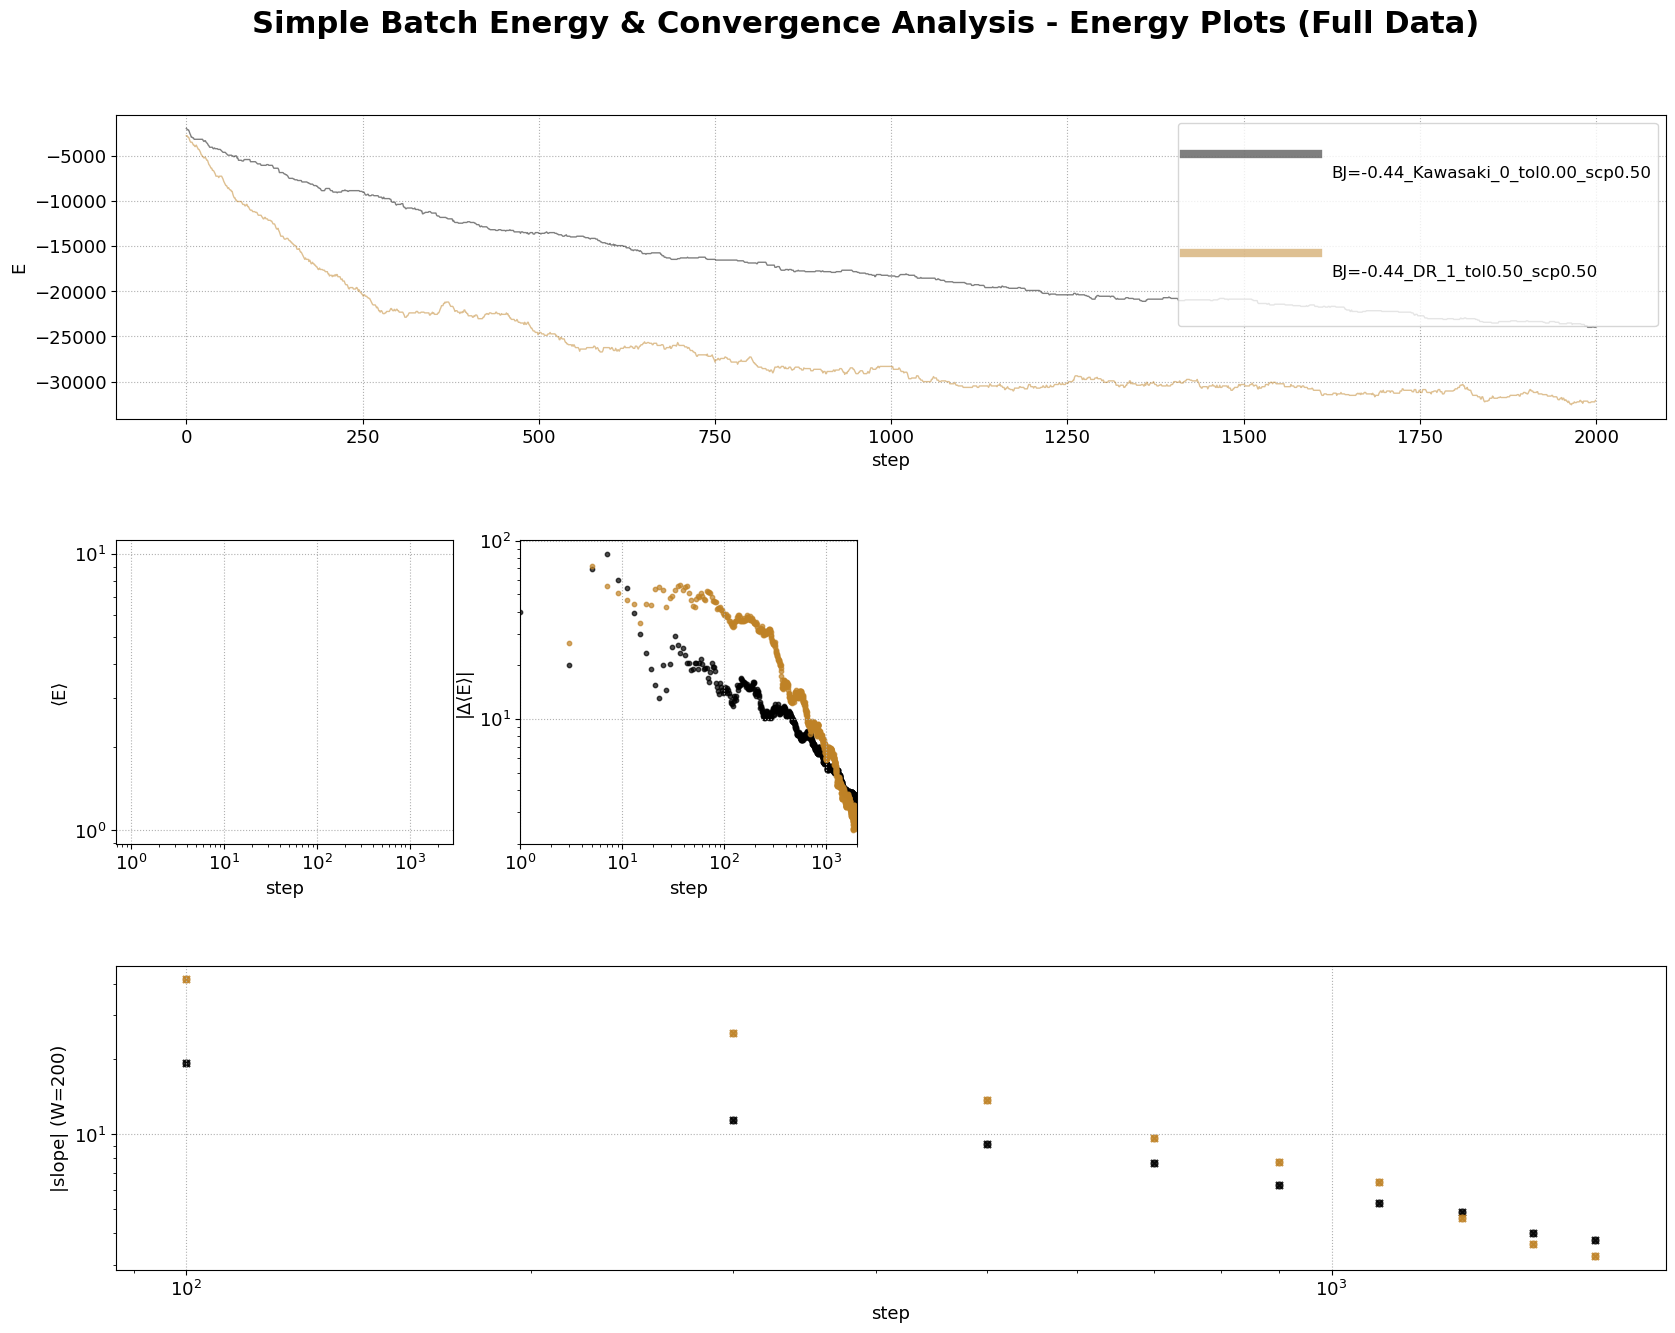

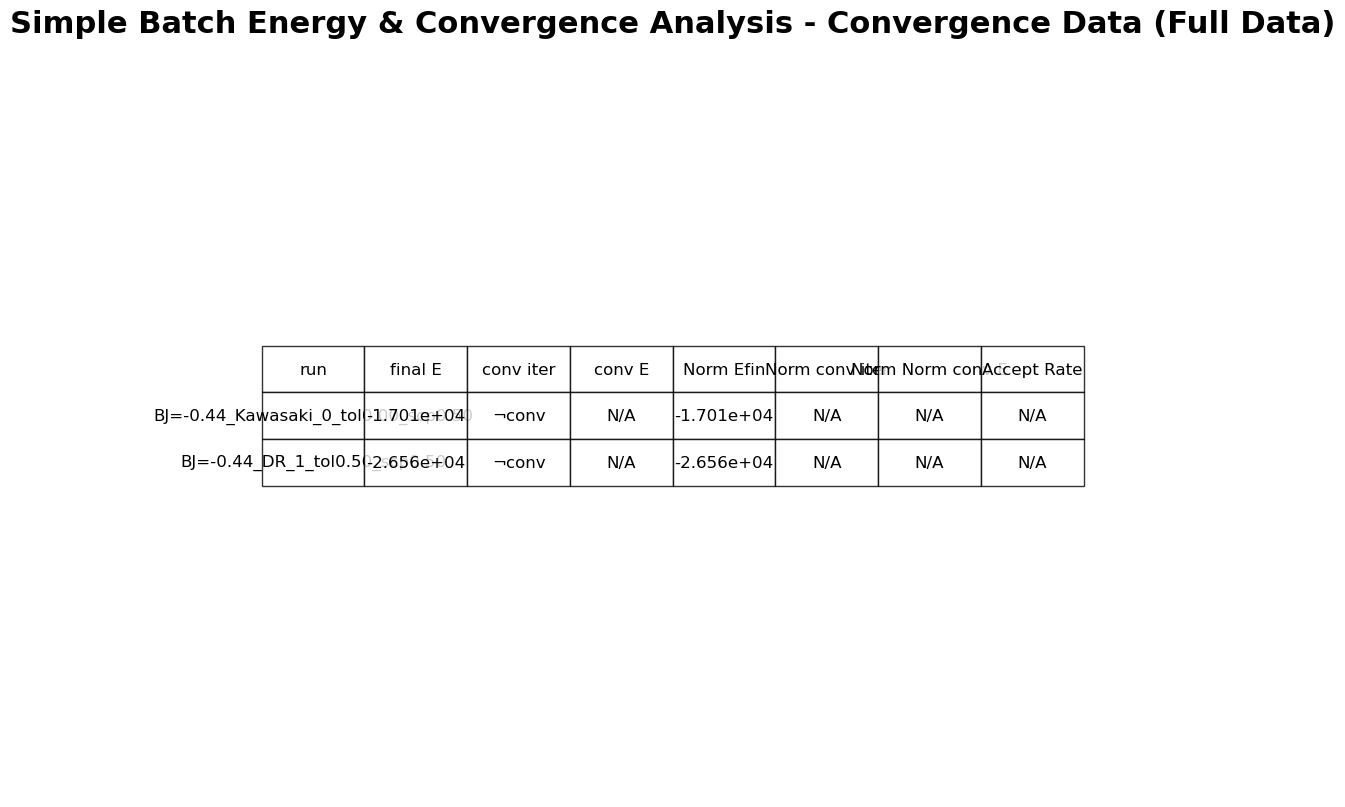

C:\Users\sabil\AppData\Local\Temp\ipykernel_21012\2675964806.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


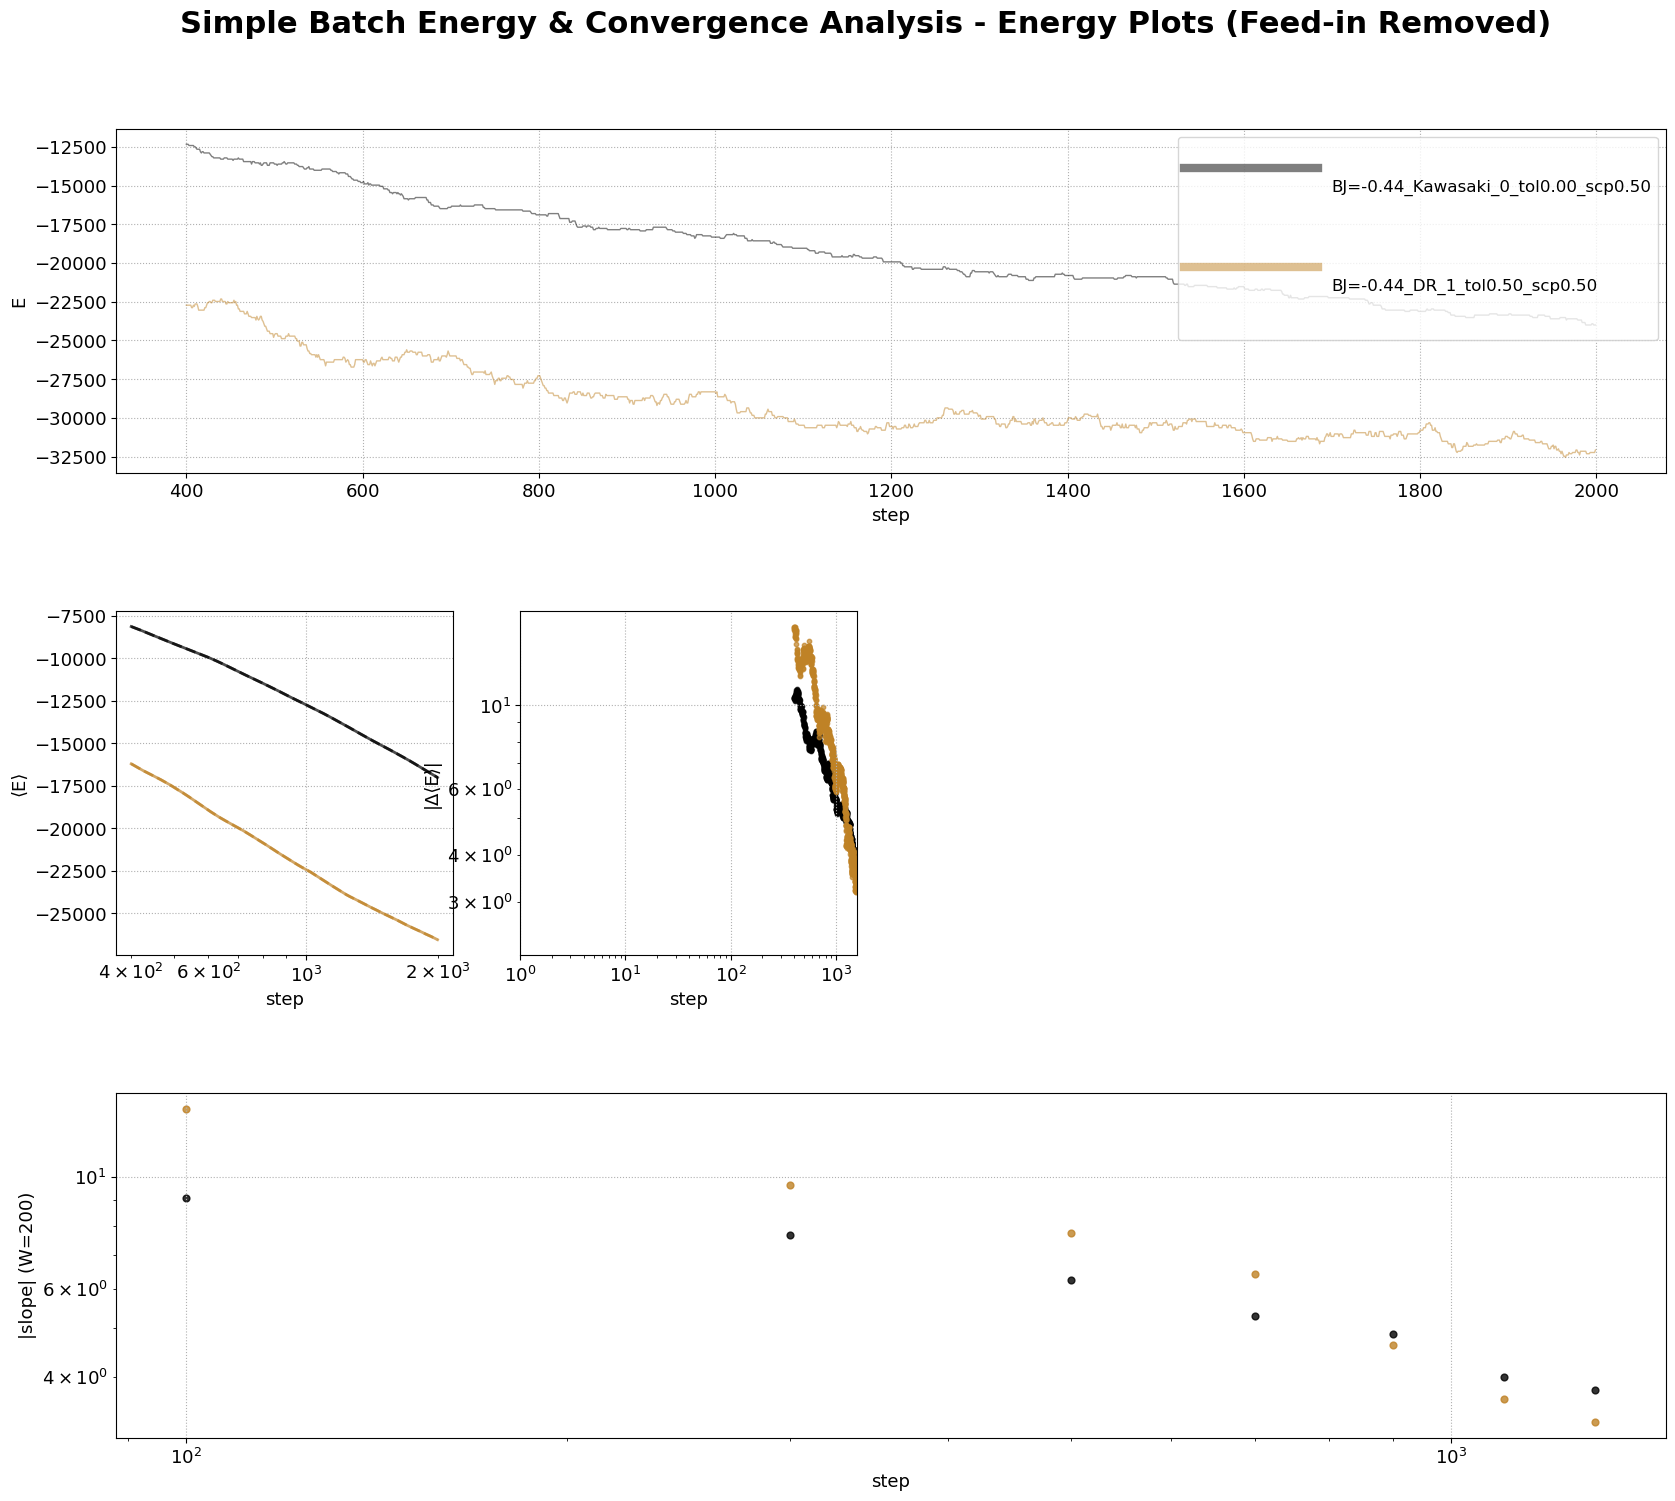

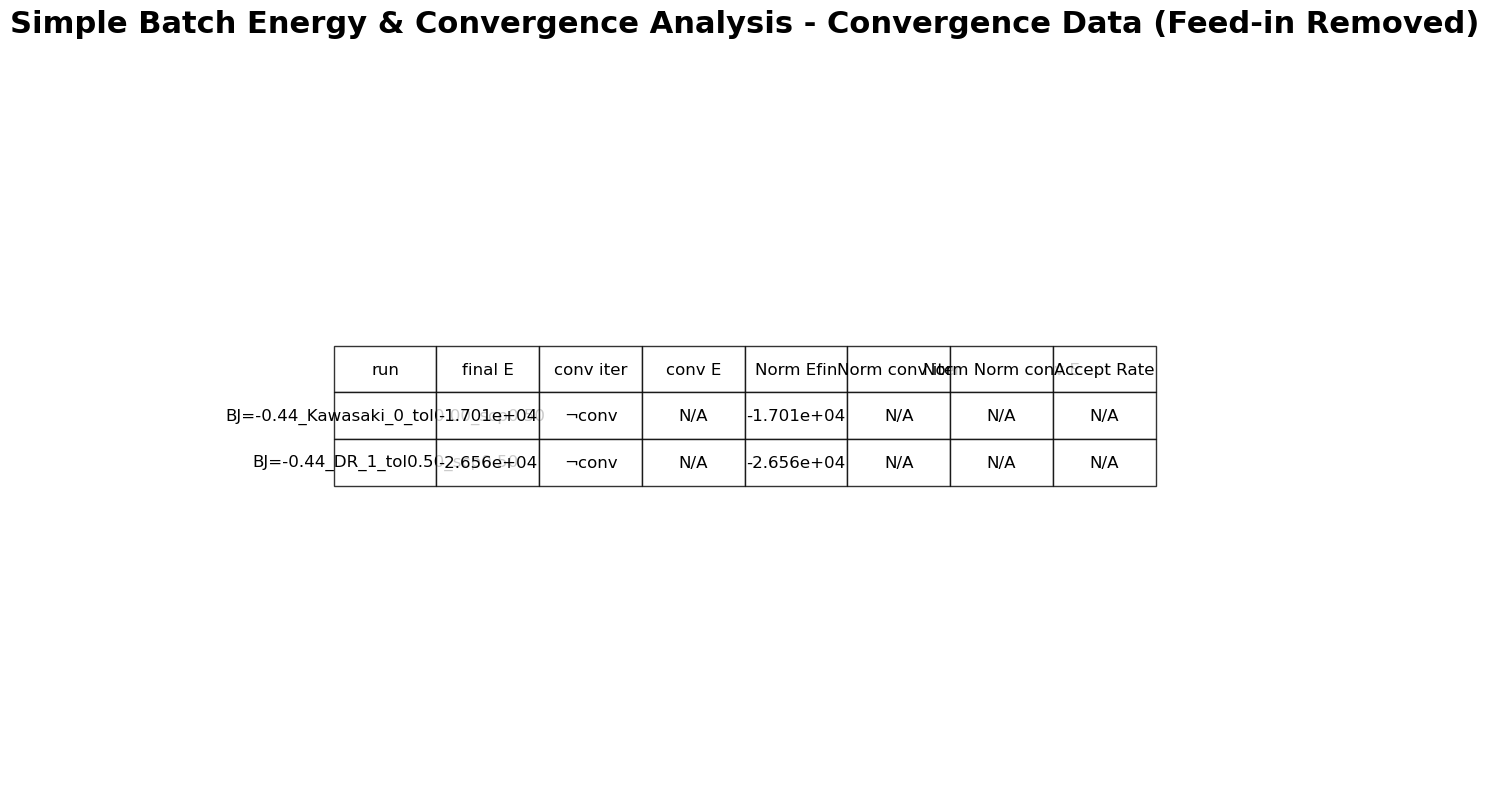

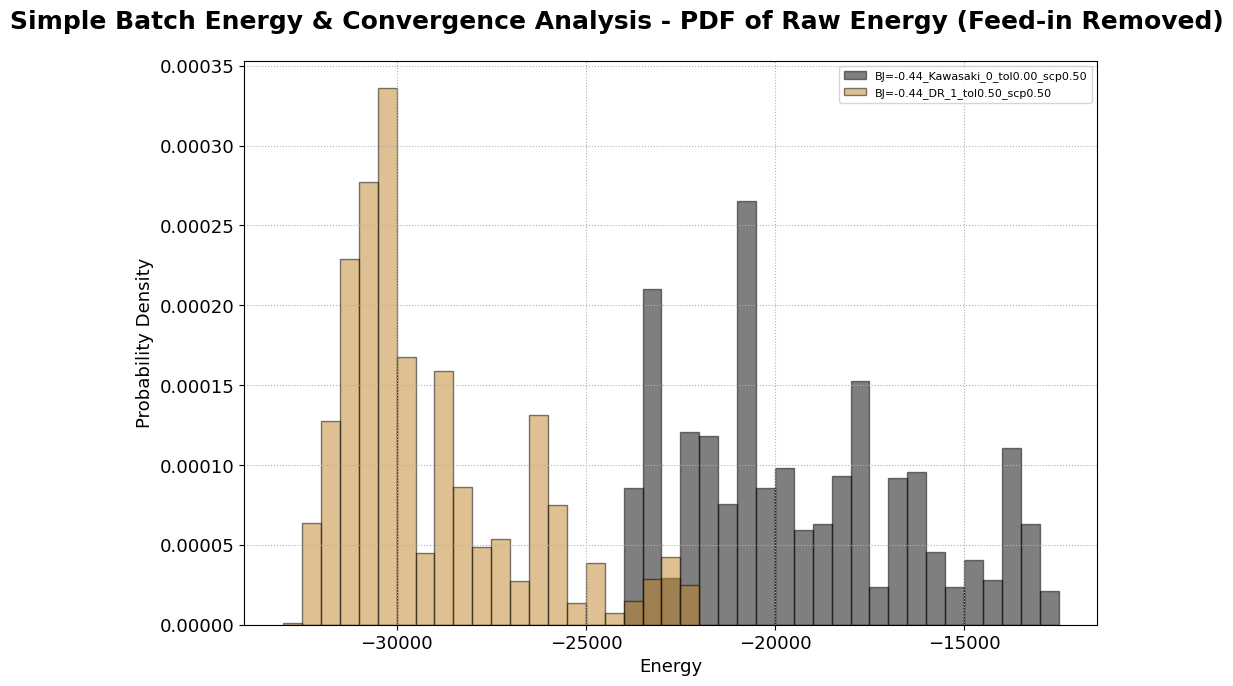


--- Running Cluster Analysis for Simple Batch ---

--- Starting Cluster Size Analysis for 2 files ---
📊 Processing BJ=-0.44_Kawasaki_0_tol0.00_scp0.50.csv: Found 2 clusters


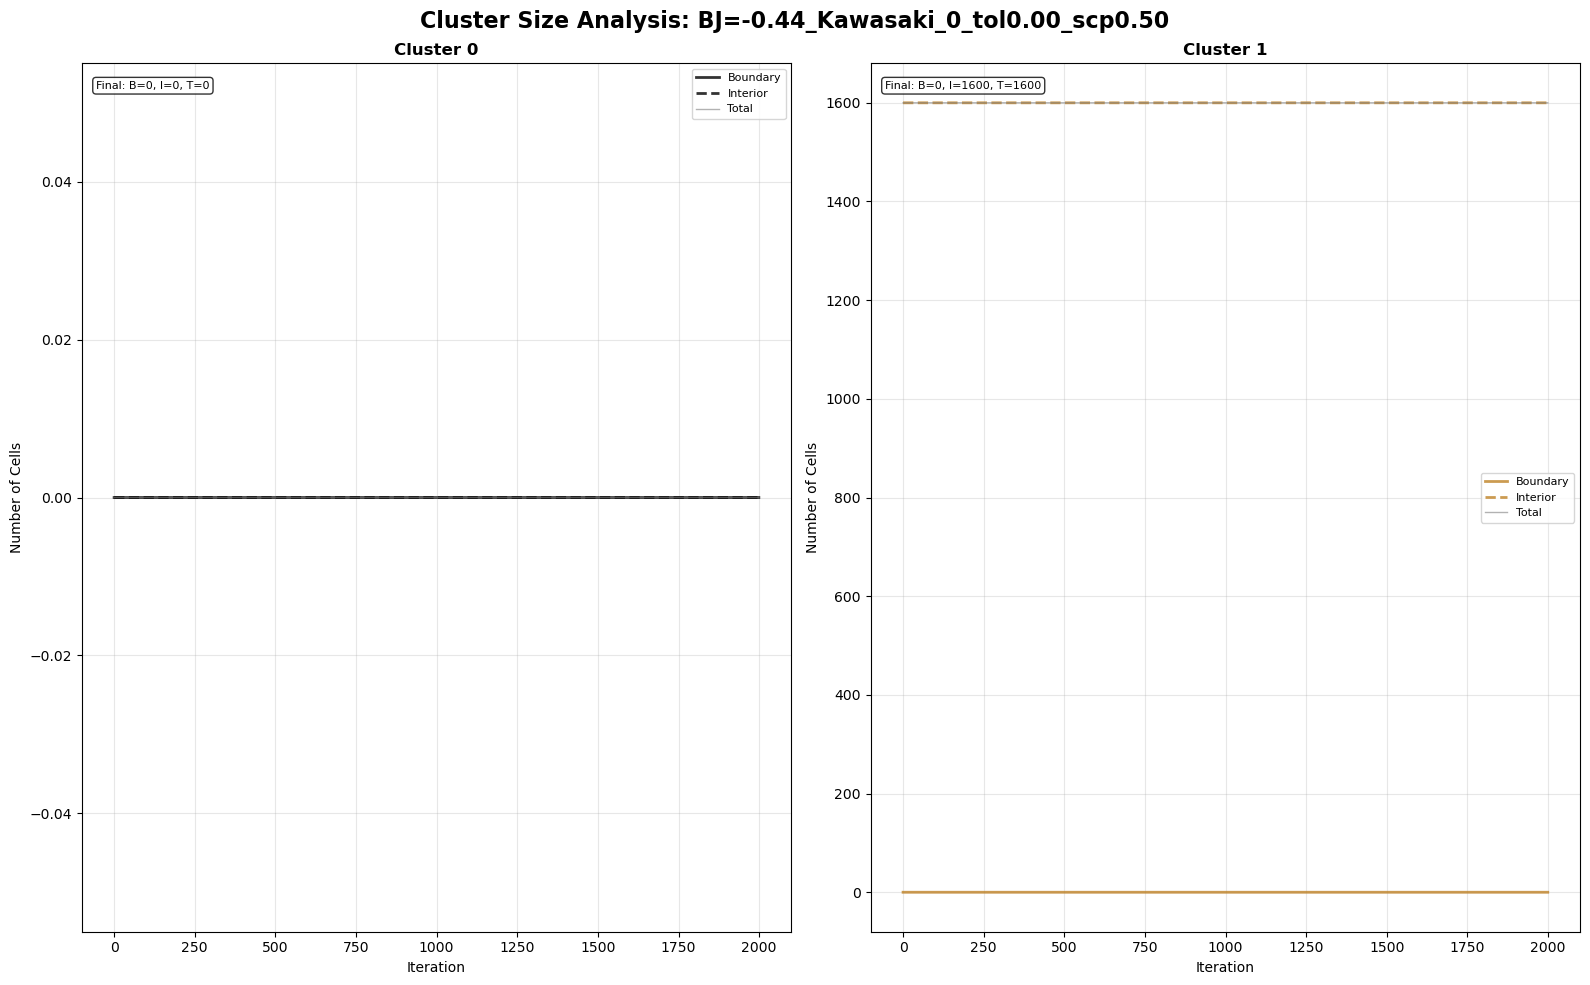


📈 Summary for BJ=-0.44_Kawasaki_0_tol0.00_scp0.50:
   Total clusters: 2
   Cluster 0: Final B=0, I=0 | Avg B=0.0, I=0.0
   Cluster 1: Final B=0, I=1600 | Avg B=0.0, I=1600.0


📊 Processing BJ=-0.44_DR_1_tol0.50_scp0.50.csv: Found 3 clusters


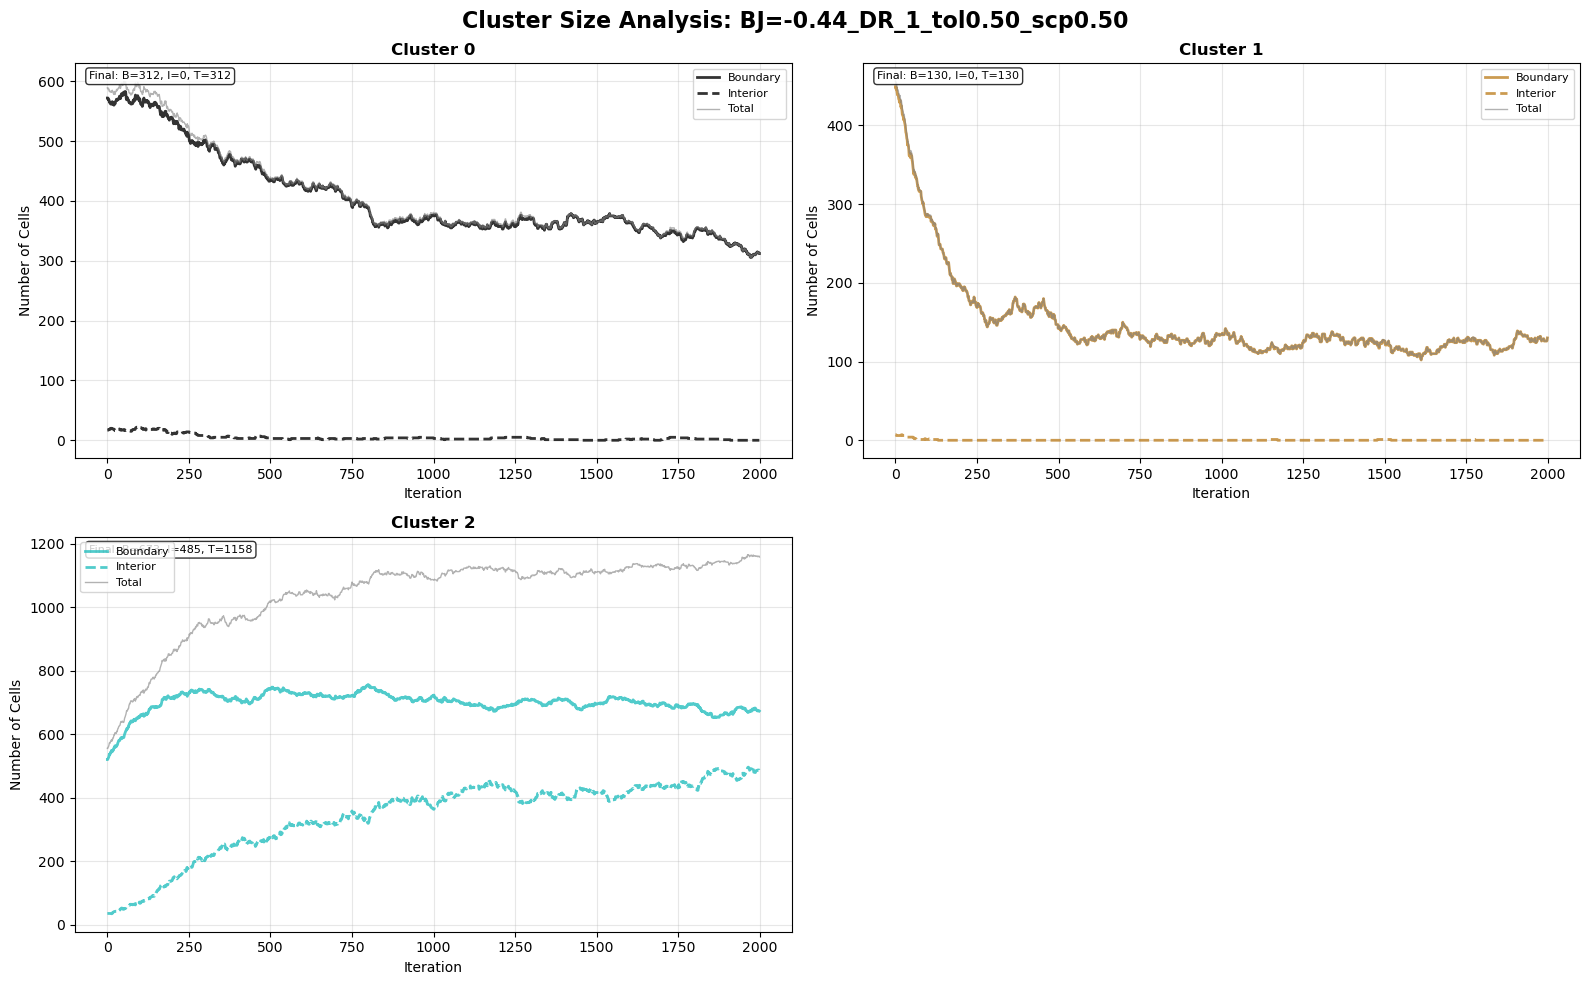


📈 Summary for BJ=-0.44_DR_1_tol0.50_scp0.50:
   Total clusters: 3
   Cluster 0: Final B=312, I=0 | Avg B=405.1, I=4.5
   Cluster 1: Final B=130, I=0 | Avg B=148.7, I=0.2
   Cluster 2: Final B=673, I=485 | Avg B=699.5, I=341.9



--- Cluster Size Analysis Complete ---

--- Running Static Grid Plots for Simple Batch ---
Debug: Plotting static grid from BJ=-0.44_Kawasaki_0_tol0.00_scp0.50_GridConfig.csv
Debug: Grid size determined as 40x40 (1600 cells)
Grid plot saved to: BJ=-0.44_Kawasaki_0_tol0.00_scp0.50_GridConfig.png


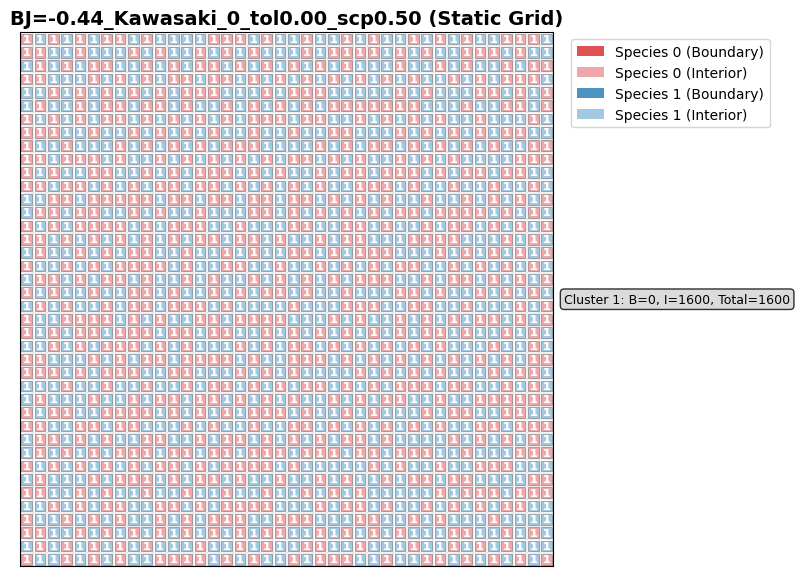

Debug: Plotting static grid from BJ=-0.44_DR_1_tol0.50_scp0.50_GridConfig.csv
Debug: Grid size determined as 40x40 (1600 cells)
Grid plot saved to: BJ=-0.44_DR_1_tol0.50_scp0.50_GridConfig.png


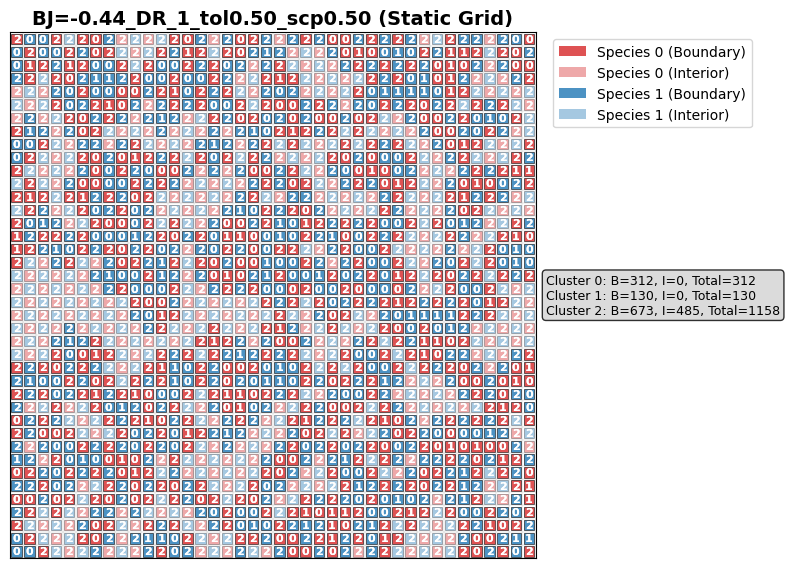


🎯 VISUALIZATION SUITE SUMMARY
📊 Energy Analysis:     compare_runs() - Energy plots, convergence analysis
📈 Cluster Analysis:    analyze_cluster_sizes() - Boundary/Interior tracking
🔲 Grid Visualization:  plot_grid() - Static grid configurations

🚀 BATCH DRIVERS:
   • simple_batch() - Streamlined processing for predefined files
   • run_visualizations() - Complex combinatoric workflow

⚙️  CLUSTER ANALYSIS OPTIONS:
   • Integrated into batch drivers with plot_clusters=True (recommended)
   • Standalone: batch_cluster_analysis() or analyze_cluster_sizes()
   • Automatically detects variable cluster counts per file
   • Shows boundary, interior, and total cluster sizes vs iterations


--- Simple Batch Visualization Complete ---


In [47]:
# ---------------------------------------------------------------------
# 7. CLI example
# ---------------------------------------------------------------------

if __name__ == '__main__':
    # Example usage for simple_batch:
    # Make sure you have CSV files named like 'BJ=-0.44_Kawasaki_0_tol0.00_scp0.50.csv',
    # and they contain the columns:
    # "GridConfigStarting", "GridConfigPotential", "PossiblyChanged", "AcceptedPossiblyChanged", "Accepted_Move"
    # in the same directory as this script.
    
    # You can customize these filenames to match your simulation outputs.
    example_filenames = [
        "BJ=-0.44_Kawasaki_0_tol0.00_scp0.50",
        "BJ=-0.44_DR_1_tol0.50_scp0.50"
    ]

    print("--- Starting Simple Batch Visualization ---", file=sys.stderr)
    simple_batch(
        *example_filenames, # Use * to unpack the list to positional arguments
        plot_energy=True,   # Set to True to generate energy plots
        plot_grids=True,    # Set to True to generate static grid plots (from first row of main CSV or separate GridConfig CSV)
        plot_clusters=True  # Set to True to generate cluster size analysis
    )
    print("--- Simple Batch Visualization Complete ---", file=sys.stderr)

    # To use the complex combinatoric workflow, you would call run_visualizations like this:
    # run_visualizations(
    #     BJ="0.5",
    #     include_kawasaki=True,
    #     base_variants=["NewMC", "DR"],
    #     signifiers=[["tol0.01", "tol0.05"], ["scp0.00", "scp0.10"]],
    #     cluster_types=["1", "2"],
    #     plot_energy=True,
    #     plot_grids=False,
    #     plot_clusters=True
    # )

# Call main or primary function here

print("\n" + "="*70)
print("🎯 VISUALIZATION SUITE SUMMARY")
print("="*70)
print("📊 Energy Analysis:     compare_runs() - Energy plots, convergence analysis")
print("📈 Cluster Analysis:    analyze_cluster_sizes() - Boundary/Interior tracking")
print("🔲 Grid Visualization:  plot_grid() - Static grid configurations")
print("")
print("🚀 BATCH DRIVERS:")
print("   • simple_batch() - Streamlined processing for predefined files")
print("   • run_visualizations() - Complex combinatoric workflow")
print("")
print("⚙️  CLUSTER ANALYSIS OPTIONS:")
print("   • Integrated into batch drivers with plot_clusters=True (recommended)")
print("   • Standalone: batch_cluster_analysis() or analyze_cluster_sizes()")
print("   • Automatically detects variable cluster counts per file")
print("   • Shows boundary, interior, and total cluster sizes vs iterations")
print("="*70)